# MedAssist-AI-IMAGE — Machine Learning para Clasificación de Imágenes

## Clasificación de medicamentos en 5 macroclases terapéuticas

Este notebook implementa un **pipeline completo de Machine Learning clásico** para clasificar imágenes de medicamentos (cajas y pastillas) en cinco macroclases terapéuticas:

1. Cardiovascular
2. Neurología y psiquiatría
3. Antiinfecciosos sistémicos
4. Respiratorio
5. Otros (agrupa las clases minoritarias)

---

## ¿Qué es el Machine Learning clásico aplicado a imágenes?

A diferencia del Deep Learning (que aprende **automáticamente** qué características son útiles para clasificar), en el ML clásico seguimos dos pasos muy diferenciados:

1. **Extracción manual de características** (*feature engineering*): transformamos cada imagen en un vector de números diseñados por nosotros, que capturan propiedades interpretables (colores dominantes, bordes, texturas…).
2. **Entrenamiento de un clasificador** sobre esos vectores (Logistic Regression, SVM, Random Forest, etc.).

**Ventajas del ML clásico**: es interpretable, entrena rápido, funciona con poco datos, y sirve como *baseline* para comparar contra modelos más complejos.

**Desventajas**: depende de que las features diseñadas a mano sean buenas. Si las imágenes son muy complejas, el DL suele ganar.

---

## Estructura del notebook

**BLOQUE 0 — Preparación**
1. Configuración e imports
2. Carga del dataset (con los splits ya hechos en el EDA)
3. Verificación del split y codificación de etiquetas

**BLOQUE 1 — Features**
4. Extracción de características (color, HOG, LBP)
5. Escalado de features

**BLOQUE 2 — Exploración**
6. Análisis de importancia y PCA + t-SNE

**BLOQUE 3 — Modelos**
7. Baselines (Dummy)
8. Logistic Regression
9. K-Nearest Neighbors (KNN)
10. Support Vector Machine (SVM)
11. Random Forest
12. Gradient Boosting

**BLOQUE 4 — Comparativa y mejor modelo**
13. Comparativa de todos los modelos
14. Optimización del mejor modelo (GridSearchCV)

**BLOQUE 5 — Ablation studies (análisis de impacto)**
15. Ablation 1: efecto del data augmentation
16. Ablation 2: efecto del balanceo de clases
17. Ablation 3: qué bloques de features aportan más

**BLOQUE 6 — Evaluación final**
18. Evaluación en el conjunto de test
19. Análisis de errores
20. Conclusiones y transición al Deep Learning


---
# BLOQUE 0 — Preparación

## 1. Configuración e imports



In [2]:
%pip install opencv-python scikit-image


  Using cached scikit_image-0.26.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (15 kB)
  Using cached imageio-2.37.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
Using cached scikit_image-0.26.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (13.6 MB)
Using cached imageio-2.37.3-py3-none-any.whl (317 kB)
Using cached lazy_loader-0.5-py3-none-any.whl (8.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-image] [scikit-image]
Note: you may need to restart the kernel to use updated packages.


In [3]:
# ── Librerías estándar ───────────────────────────────────────────────────────
import warnings, random, os, time
from pathlib import Path
warnings.filterwarnings('ignore')

# ── Cálculo numérico y datos ─────────────────────────────────────────────────
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# ── Procesamiento de imágenes ────────────────────────────────────────────────
from PIL import Image
import cv2
from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2gray

# ── Machine Learning (scikit-learn) ──────────────────────────────────────────
# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier

# Preprocesamiento y validación
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

# Métricas
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

# ── Visualización ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# ── Persistencia ─────────────────────────────────────────────────────────────
import joblib

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURACIÓN GLOBAL
# ─────────────────────────────────────────────────────────────────────────────
SEED     = 42
IMG_SIZE = (224, 224)   # Tamaño al que redimensionamos todas las imágenes

# Reproducibilidad: fijamos la semilla en todas las librerías aleatorias
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Clases con las que vamos a trabajar (definidas en el EDA)
CLASES = [
    'Cardiovascular',
    'Neurología y psiquiatría',
    'Antiinfecciosos sistémicos',
    'Respiratorio',
    'otros'
]

# Paleta de colores fija por clase (para que los gráficos sean consistentes)
PALETTE = dict(zip(CLASES, ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']))

# Rutas
CSV_BALANCED = 'output/dataset_balanced.csv'
CSV_ORIGINAL = 'output/dataset_split.csv'   # fallback por si no hay balanceado
OUTPUT_DIR   = Path('output_ml')
OUTPUT_DIR.mkdir(exist_ok=True)

# Estilo de gráficos
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
})
sns.set_style('whitegrid')

print(f'✔ Configuración cargada | SEED={SEED} | IMG_SIZE={IMG_SIZE}')
print(f'  Clases a clasificar: {len(CLASES)}')
for i, c in enumerate(CLASES):
    print(f'    {i}. {c}')


✔ Configuración cargada | SEED=42 | IMG_SIZE=(224, 224)
  Clases a clasificar: 5
    0. Cardiovascular
    1. Neurología y psiquiatría
    2. Antiinfecciosos sistémicos
    3. Respiratorio
    4. otros


## 2. Carga del dataset

### ¿Qué CSV cargamos?

En el notebook anterior (EDA) ya hicimos un trabajo importantísimo:

1. Elegimos las 5 macroclases de trabajo.
2. **Dividimos en train/val/test de forma estratificada por `nregistro`** (es decir, todas las imágenes de un mismo medicamento caen en el mismo split; esto es crucial para evitar data leakage).
3. **Generamos imágenes sintéticas con data augmentation solo en train** para balancear las clases.

Todo esto quedó guardado en `dataset_balanced.csv`. Cargamos ese CSV directamente en lugar de rehacer el trabajo, y así **garantizamos que el split es idéntico al que usaremos en el Deep Learning**, haciendo las comparaciones justas.

Si por alguna razón no existe el CSV balanceado, cargamos la versión sin augmentation (`dataset_split.csv`).


In [4]:
# Cargar el CSV balanceado (o el split sin augmentation como fallback)
if Path(CSV_BALANCED).exists():
    df = pd.read_csv(CSV_BALANCED, dtype={'nregistro': str})
    print(f'Cargado: {CSV_BALANCED}')
elif Path(CSV_ORIGINAL).exists():
    df = pd.read_csv(CSV_ORIGINAL, dtype={'nregistro': str})
    df['augmented'] = False
    print(f'CSV balanceado no encontrado. Usando: {CSV_ORIGINAL}')
else:
    raise FileNotFoundError('Ejecuta primero el notebook de EDA para generar los CSVs.')

# Limpieza: eliminar filas sin clase o sin ruta de imagen
df = df[df['clase'].notna() & df['image_path'].notna()].copy().reset_index(drop=True)

# ── Resumen del dataset cargado ──────────────────────────────────────────────
print('\n' + '=' * 60)
print('  RESUMEN DEL DATASET')
print('=' * 60)
print(f'  Total filas:                {len(df):>8,}')
print(f'  Medicamentos únicos:        {df["nregistro"].nunique():>8,}')
print(f'  Imágenes originales:        {(~df["augmented"]).sum():>8,}')
print(f'  Imágenes sintéticas (aug):  {df["augmented"].sum():>8,}')

print('\n  Distribución por split:')
print(df.groupby(['split', 'augmented']).size()
      .unstack(fill_value=0).to_string())
print('\n  Distribución de clases (total):')
print(df['clase'].value_counts().reindex(CLASES).to_string())


Cargado: output/dataset_balanced.csv

  RESUMEN DEL DATASET
  Total filas:                  20,486
  Medicamentos únicos:           5,021
  Imágenes originales:           9,998
  Imágenes sintéticas (aug):    10,488

  Distribución por split:
augmented  False  True 
split                  
test        1499      0
train       6999  10488
val         1500      0

  Distribución de clases (total):
clase
Cardiovascular                4045
Neurología y psiquiatría      3979
Antiinfecciosos sistémicos    3731
Respiratorio                  3709
otros                         5022


### Interpretación del resumen

Deberíamos ver:
- **Train** con aprox. 70% de los medicamentos, y con imágenes marcadas como `augmented=True` (las sintéticas del EDA).
- **Val** y **Test** con aprox. 15% cada uno, y **sin ninguna imagen aumentada** (esto es clave: si hubiera augmentation en val/test estaríamos haciendo trampa, porque esas imágenes derivan de otras originales y el modelo podría haber visto versiones muy similares en train).
- El número de imágenes por clase en train debe ser similar entre clases gracias al augmentation.


## 3. Verificación del split y codificación de etiquetas

### ¿Qué es data leakage y por qué lo verificamos?

**Data leakage** ocurre cuando información de validación o test se "filtra" al entrenamiento, inflando artificialmente las métricas. En este proyecto, dos leakages posibles:

1. **Mismo `nregistro` en dos splits**: si un medicamento tiene 3 fotos y 2 van a train y 1 a val, el modelo ya "conoce" ese medicamento en val → métricas infladas.
2. **Imágenes aumentadas en val/test**: la augmentation deriva de originales. Si una imagen aug de una foto de train estuviera en val, sería casi data leakage.

El EDA ya tuvo esto en cuenta, pero **revalidamos** para dar tranquilidad.

### ¿Qué es LabelEncoder?

Los modelos de sklearn no entienden strings. Necesitan números. `LabelEncoder` convierte cada clase (string) en un entero: `"Cardiovascular" → 0`, `"Neurología..." → 1`, etc. Hacemos `fit` sobre la lista fija `CLASES` para que el mapeo sea determinista (no dependa del orden del CSV).


In [5]:
# ── Construir DataFrames por split ───────────────────────────────────────────
df_train = df[df['split'] == 'train'].reset_index(drop=True)
df_val   = df[df['split'] == 'val'].reset_index(drop=True)
df_test  = df[df['split'] == 'test'].reset_index(drop=True)

# ── Verificación de ausencia de leakage ──────────────────────────────────────
regs_train = set(df_train['nregistro'])
regs_val   = set(df_val['nregistro'])
regs_test  = set(df_test['nregistro'])

leak_tv = len(regs_train & regs_val)
leak_tt = len(regs_train & regs_test)
leak_vt = len(regs_val   & regs_test)

print('─' * 55)
print('  VERIFICACIÓN DE LEAKAGE')
print('─' * 55)
print(f'  Train ∩ Val:   {leak_tv} medicamentos  '
      f'{"OK" if leak_tv == 0 else " LEAKAGE"}')
print(f'  Train ∩ Test:  {leak_tt} medicamentos  '
      f'{" OK" if leak_tt == 0 else "LEAKAGE"}')
print(f'  Val   ∩ Test:  {leak_vt} medicamentos  '
      f'{" OK" if leak_vt == 0 else "LEAKAGE"}')
print(f'\n  Imágenes aumentadas en val:  {df_val["augmented"].sum()}  '
      f'{"OK" if df_val["augmented"].sum() == 0 else " FUGA"}')
print(f'  Imágenes aumentadas en test: {df_test["augmented"].sum()}  '
      f'{" OK" if df_test["augmented"].sum() == 0 else " FUGA"}')

# ── Codificación de etiquetas ────────────────────────────────────────────────
le = LabelEncoder()
le.fit(CLASES)  # orden determinista

print('\n  Codificación de clases:')
for i, cls in enumerate(le.classes_):
    print(f'    {i}  →  {cls}')


───────────────────────────────────────────────────────
  VERIFICACIÓN DE LEAKAGE
───────────────────────────────────────────────────────
  Train ∩ Val:   0 medicamentos  OK
  Train ∩ Test:  0 medicamentos   OK
  Val   ∩ Test:  0 medicamentos   OK

  Imágenes aumentadas en val:  0  OK
  Imágenes aumentadas en test: 0   OK

  Codificación de clases:
    0  →  Antiinfecciosos sistémicos
    1  →  Cardiovascular
    2  →  Neurología y psiquiatría
    3  →  Respiratorio
    4  →  otros


---
# BLOQUE 1 — Extracción de características (features)

## 4. ¿Qué features vamos a extraer y por qué?

Una imagen RGB de 224×224 tiene **150.528 valores** (224×224×3). Si se los damos tal cual a un clasificador clásico como un SVM, tendríamos un problema: demasiadas dimensiones, modelo lento, y la mayoría de esos píxeles son **redundantes**.

La solución es **extraer características** diseñadas a mano que resuman la imagen en unos pocos cientos de números informativos. Vamos a usar **tres tipos de features complementarias**:

### a) Color (histograma HSV con pirámide espacial) — captura "¿de qué colores es?"

- HSV es el espacio de color donde H = tono (rojo, azul, verde…), S = saturación, V = brillo.
- **HSV es mejor que RGB** para clasificar porque separa el color (H) de la iluminación (V). Dos fotos del mismo objeto con luz diferente tienen RGB muy distintos pero H similar.
- **Pirámide espacial 2×2**: dividimos la imagen en 4 cuadrantes y calculamos un histograma por cuadrante. Así capturamos "el azul está arriba-izquierda, el blanco abajo-derecha". Un histograma global perdería esa información de posición.

### b) HOG (Histogram of Oriented Gradients) — captura "¿qué formas y bordes tiene?"

- HOG detecta las direcciones de los bordes (horizontales, verticales, diagonales…).
- Es el feature clásico para detectar objetos con formas definidas (cajas rectangulares, pastillas redondas u ovaladas, texto impreso en envases…).
- Introducido por Dalal & Triggs (2005); sigue siendo un estándar.

### c) LBP (Local Binary Patterns) — captura "¿qué texturas tiene?"

- LBP compara cada píxel con sus vecinos y codifica el patrón en un byte.
- Detecta texturas finas: superficies lisas vs. rugosas, patrones regulares (por ejemplo, las bandas de una caja de medicamento).
- Es **invariante a cambios monotónicos de iluminación** (el patrón local no cambia si toda la imagen se oscurece).

### ¿Por qué combinar los tres?

Cada feature ve algo distinto. Un antihipertensivo puede tener envase **azul** (color), forma **rectangular** (HOG) y cierta **textura** del diseño gráfico (LBP). Combinar los tres da al clasificador una representación rica de la imagen.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# FUNCIONES DE EXTRACCIÓN DE FEATURES
# ─────────────────────────────────────────────────────────────────────────────

def extract_color_histogram(img_rgb, bins=32, grid=(2, 2)):
    """
    Histograma HSV con pirámide espacial.

    Proceso:
      1. Convierte RGB → HSV (más robusto a cambios de iluminación).
      2. Divide la imagen en una cuadrícula (por defecto 2×2 = 4 celdas).
      3. Por cada celda, calcula un histograma del canal H (tono) con 32 bins.
      4. Normaliza cada histograma (L1) y concatena los 4 vectores.

    Dimensión de salida: bins × (grid[0] × grid[1]) = 32 × 4 = 128 features
    """
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    h, w = hsv.shape[:2]
    rows, cols = grid
    cell_h, cell_w = h // rows, w // cols

    features = []
    for r in range(rows):
        for c in range(cols):
            # Extraer celda (r, c) del canal H
            patch = hsv[r*cell_h:(r+1)*cell_h, c*cell_w:(c+1)*cell_w, 0]
            hist, _ = np.histogram(patch, bins=bins, range=(0, 180))
            # Normalización L1 (dividir por la suma) → invariante al tamaño de celda
            hist = hist.astype(float)
            if hist.sum() > 0:
                hist /= hist.sum()
            features.append(hist)

    return np.concatenate(features)


def extract_hog_features(img_rgb, img_size=(128, 128)):
    """
    HOG (Histogram of Oriented Gradients).

    Proceso:
      1. Pasa a escala de grises (HOG no usa color).
      2. Redimensiona a 128×128 (más pequeño = más rápido).
      3. Divide en celdas de 16×16 píxeles.
      4. Por cada celda, calcula un histograma de 9 orientaciones de gradiente.
      5. Normaliza en bloques de 2×2 celdas (robusto a iluminación local).

    Configuración estándar de Dalal & Triggs (2005).
    Dimensión variable según tamaño (con estos params ≈ 1764 features).
    """
    gray = rgb2gray(np.array(Image.fromarray(img_rgb).resize(img_size, Image.BILINEAR)))
    features = hog(
        gray,
        orientations=9,              # 9 bins angulares (0°–180°)
        pixels_per_cell=(16, 16),    # celdas de 16×16 px
        cells_per_block=(2, 2),      # normalización en bloques de 2×2 celdas
        block_norm='L2-Hys',         # normalización robusta (Hys = con clipping)
        feature_vector=True
    )
    return features.astype(np.float32)


def extract_lbp_features(img_rgb, radius=3, n_points=24, img_size=(128, 128)):
    """
    LBP (Local Binary Patterns) uniforme.

    Proceso:
      1. Pasa a escala de grises.
      2. Para cada píxel, compara con sus `n_points=24` vecinos en un círculo de `radius=3`.
      3. Codifica el patrón en un byte (1 si el vecino es más claro, 0 si no).
      4. Variante "uniform": solo considera patrones con ≤ 2 transiciones 0↔1.
         Esto reduce de 2^24 patrones posibles a solo 26, y son los más informativos
         (bordes, esquinas, líneas).
      5. Calcula histograma normalizado de los códigos.

    Dimensión: n_points + 2 = 26 features
    """
    gray = rgb2gray(np.array(Image.fromarray(img_rgb).resize(img_size, Image.BILINEAR)))
    lbp  = local_binary_pattern(gray, P=n_points, R=radius, method='uniform')
    n_bins = n_points + 2
    hist, _ = np.histogram(lbp, bins=n_bins, range=(0, n_bins), density=True)
    return hist.astype(np.float32)


def extract_features(image_path):
    """
    Extrae los 3 bloques de features de una imagen y los devuelve en un dict.

    Devolvemos un dict (no un array concatenado) porque más adelante, en el
    ablation study, querremos entrenar modelos usando solo algunos bloques.
    """
    try:
        img = Image.open(image_path).convert('RGB').resize(IMG_SIZE, Image.BILINEAR)
        arr = np.array(img)
    except Exception:
        return None

    return {
        'color': extract_color_histogram(arr),
        'hog':   extract_hog_features(arr),
        'lbp':   extract_lbp_features(arr),
    }


# ── Probamos con una imagen para ver las dimensiones ─────────────────────────
sample_path = df_train.iloc[0]['image_path']
sample_feats = extract_features(sample_path)

if sample_feats is not None:
    FEATURE_DIMS = {k: len(v) for k, v in sample_feats.items()}
    TOTAL_DIMS   = sum(FEATURE_DIMS.values())
    print('─' * 50)
    print('  DIMENSIONES POR BLOQUE DE FEATURES')
    print('─' * 50)
    for k, d in FEATURE_DIMS.items():
        print(f'  {k:<10} {d:>5,} features')
    print('─' * 50)
    print(f'  TOTAL      {TOTAL_DIMS:>5,} features por imagen')
else:
    raise RuntimeError(f'No se pudo leer {sample_path}')


RuntimeError: No se pudo leer /Users/merybri/Library/CloudStorage/OneDrive-UPNA/master_clases/segundo semestre/analisis de datos no estructurados/proyecto_imagen/MedAssist-AI-IMAGE/imagenes/a_a_s_500_mg_comprimidos__42956__materialas__0003.jpg

### Interpretación del resultado

Cada imagen se resume en aproximadamente 1.900 números. Esto es muchísimo menos que los 150.528 valores de píxeles crudos, pero concentra la información relevante.

- **HOG** es el bloque más grande (1.764 dims) porque divide la imagen en muchas celdas.
- **Color** aporta 128 dims (el HSV en 4 cuadrantes con 32 bins).
- **LBP** es el más compacto (26 dims) pero muy informativo en texturas.


## 5. Extracción masiva de features

Ahora aplicamos el pipeline de extracción a todas las imágenes de train, val y test.

### ¿Por qué usar caché?

Extraer features para miles de imágenes tarda varios minutos. Si cerramos el notebook y lo volvemos a abrir, no queremos repetir ese cálculo. Guardamos los resultados en disco (`feature_cache/`) con `joblib.dump` y la próxima vez se cargan en segundos.


In [5]:
CACHE_DIR = Path('feature_cache')
CACHE_DIR.mkdir(exist_ok=True)
CACHE_VERSION = 'v3_color_hog_lbp'


def extract_features_batch(df_split, split_name, force=False):
    """
    Extrae features para todas las imágenes de un split.
    Guarda/carga de caché.
    """
    cache_path = CACHE_DIR / f'feats_{CACHE_VERSION}_{split_name}.pkl'

    if cache_path.exists() and not force:
        print(f'  [{split_name}] Cargando caché: {cache_path.name}')
        return joblib.load(cache_path)

    print(f'  [{split_name}] Extrayendo {len(df_split):,} imágenes...')
    t0 = time.time()

    blocks = {'color': [], 'hog': [], 'lbp': []}
    labels, valid_idx = [], []

    for i, row in enumerate(tqdm(df_split.itertuples(), total=len(df_split), desc=split_name)):
        feats = extract_features(row.image_path)
        if feats is None:
            continue
        for k in blocks:
            blocks[k].append(feats[k])
        labels.append(le.transform([row.clase])[0])
        valid_idx.append(i)

    result = {
        'blocks':       {k: np.stack(v).astype(np.float32) for k, v in blocks.items()},
        'y':            np.array(labels, dtype=np.int32),
        'valid_idx':    np.array(valid_idx),
        'feature_dims': {k: np.stack(v).shape[1] for k, v in blocks.items()},
    }
    joblib.dump(result, cache_path)

    print(f'  [{split_name}] ✔ {len(valid_idx):,} imágenes procesadas en {time.time()-t0:.0f}s')
    return result


# Extraer para los 3 splits
print('Extrayendo features (tarda la primera vez)...\n')
feats_train = extract_features_batch(df_train, 'train')
feats_val   = extract_features_batch(df_val,   'val')
feats_test  = extract_features_batch(df_test,  'test')

# Construir matrices X concatenando los 3 bloques
def concat_blocks(feats, blocks=('color', 'hog', 'lbp')):
    return np.concatenate([feats['blocks'][k] for k in blocks], axis=1)

X_train = concat_blocks(feats_train)
X_val   = concat_blocks(feats_val)
X_test  = concat_blocks(feats_test)

y_train = feats_train['y']
y_val   = feats_val['y']
y_test  = feats_test['y']

# Flag de si la fila de train es una imagen aumentada (para ablation después)
is_aug_train = df_train.iloc[feats_train['valid_idx']]['augmented'].values

print(f'\n── Matrices finales ──')
print(f'  X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'  X_val:   {X_val.shape}  y_val:   {y_val.shape}')
print(f'  X_test:  {X_test.shape}  y_test:  {y_test.shape}')


Extrayendo features (tarda la primera vez)...

  [train] Cargando caché: feats_v3_color_hog_lbp_train.pkl
  [val] Cargando caché: feats_v3_color_hog_lbp_val.pkl
  [test] Cargando caché: feats_v3_color_hog_lbp_test.pkl

── Matrices finales ──
  X_train: (6971, 1918)  y_train: (6971,)
  X_val:   (1493, 1918)  y_val:   (1493,)
  X_test:  (1492, 1918)  y_test:  (1492,)


## 6. Escalado de features (StandardScaler)

### ¿Por qué hay que escalar?

Nuestras features tienen **escalas muy distintas**:
- Los histogramas de color están normalizados entre 0 y 1.
- Los valores de HOG están entre 0 y ~0.3.
- Los valores de LBP están entre 0 y 1.

Modelos como **Logistic Regression, SVM y KNN** son **sensibles a la escala** porque calculan distancias o gradientes. Si una feature tiene valores 100 veces más grandes que otra, dominará la decisión aunque no sea más informativa.

**StandardScaler** hace que cada feature tenga:
- Media = 0
- Desviación estándar = 1

### fit solo con train

Esto es crucial. Si ajustáramos el scaler usando val y test, estaríamos mirando esos datos y contaminando la evaluación. El scaler debe "aprender" la media y std solo de train y luego aplicar esa misma transformación a val y test.


In [6]:
scaler = StandardScaler()
# fit_transform sobre train: aprende media y std Y transforma
X_train_sc = scaler.fit_transform(X_train)
# transform sobre val y test: usa la media/std aprendidas de train
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print('StandardScaler ajustado únicamente sobre TRAIN')
print('─' * 55)
print(f'  X_train_sc:  media ≈ {X_train_sc.mean():+.3f}   std ≈ {X_train_sc.std():.3f}')
print(f'  X_val_sc:    media ≈ {X_val_sc.mean():+.3f}   std ≈ {X_val_sc.std():.3f}')
print(f'  X_test_sc:   media ≈ {X_test_sc.mean():+.3f}   std ≈ {X_test_sc.std():.3f}')

# Guardar scaler para reutilizar después
joblib.dump(scaler, OUTPUT_DIR / 'scaler.pkl')
print(f'\n✔ Scaler guardado en {OUTPUT_DIR / "scaler.pkl"}')


StandardScaler ajustado únicamente sobre TRAIN
───────────────────────────────────────────────────────
  X_train_sc:  media ≈ -0.000   std ≈ 1.000
  X_val_sc:    media ≈ +0.004   std ≈ 1.008
  X_test_sc:   media ≈ -0.003   std ≈ 1.002

✔ Scaler guardado en output_ml/scaler.pkl


### Interpretación

- `X_train_sc` tiene media con valor de 0 y std con valor 1 (es lo que `fit_transform` garantiza).
- `X_val_sc` y `X_test_sc` deberían tener medias y std **cercanas a 0 y 1 pero no exactas**. Si fueran muy diferentes (p. ej. media = 2), significaría que la distribución de val/test es muy distinta de la de train → distribución shift → problema. En este caso como son cercanas a 0 y 1, confirmamos que no hay un shift fuerte entre los splits.


---
# BLOQUE 2 — Exploración de features

## 7. ¿Qué bloques de features son más importantes? (PCA y t-SNE)

Antes de entrenar los modelos serios, hacemos dos análisis para "tantear" si nuestras features son suficientes para separar las clases.

### 7.1 PCA — ¿Cuánta información tenemos y cuántas dimensiones necesitamos?

**PCA (Principal Component Analysis)** encuentra nuevas direcciones (*componentes principales*) que son combinaciones lineales de las features originales, ordenadas por cuánta varianza capturan. Sirve para dos cosas:

1. **Reducir dimensionalidad**: si los primeros 100 componentes explican el 95% de la varianza, podemos pasar de 1.900 features a 100 sin perder casi nada de información. Esto acelera muchísimo el entrenamiento del SVM.
2. **Diagnóstico**: si con muy pocos componentes ya explicamos la mayoría de la varianza, significa que hay **redundancia** entre features.

### 7.2 t-SNE — ¿Se ven agrupadas las clases en el espacio de features?

**t-SNE** proyecta los datos a 2D intentando preservar la vecindad local. Si al pintar los puntos coloreados por clase vemos **grupos separados**, nuestras features contienen señal útil para el clasificador. Si vemos una nube mezclada, el problema será muy difícil.


In [7]:
# ── PCA sobre los datos escalados ────────────────────────────────────────────
# Ajustamos un PCA con muchos componentes (hasta 200) para analizar la varianza
pca_analisis = PCA(n_components=0.95, svd_solver='full', random_state=SEED)
pca_analisis.fit(X_train_sc)

# Varianza acumulada: ¿cuántos componentes necesitamos para cubrir X% de la info?
var_acumulada = np.cumsum(pca_analisis.explained_variance_ratio_)

n_comp_90 = int(np.searchsorted(var_acumulada, 0.90)) + 1
n_comp_95 = int(np.searchsorted(var_acumulada, 0.95)) + 1
n_comp_99 = int(np.searchsorted(var_acumulada, 0.99)) + 1

print(f'Componentes necesarios para explicar:')
print(f'  90% de la varianza:   {n_comp_90:>4} componentes')
print(f'  95% de la varianza:   {n_comp_95:>4} componentes')
print(f'  99% de la varianza:   {n_comp_99:>4} componentes')
print(f'  (features originales: {X_train_sc.shape[1]:,})')

# Ajustar PCA final con 95% de varianza y transformar todos los splits
# Lo usaremos con los modelos que prefieren pocas dimensiones (SVM, KNN)
pca_95 = PCA(n_components=n_comp_95, random_state=SEED)
X_train_pca = pca_95.fit_transform(X_train_sc)
X_val_pca   = pca_95.transform(X_val_sc)
X_test_pca  = pca_95.transform(X_test_sc)

print(f'\nMatrices con PCA 95%: X_train_pca.shape = {X_train_pca.shape}')


Componentes necesarios para explicar:
  90% de la varianza:    390 componentes
  95% de la varianza:    601 componentes
  99% de la varianza:    602 componentes
  (features originales: 1,918)

Matrices con PCA 95%: X_train_pca.shape = (6971, 601)


Calculando t-SNE sobre 1,500 muestras (esto tarda unos segundos)...


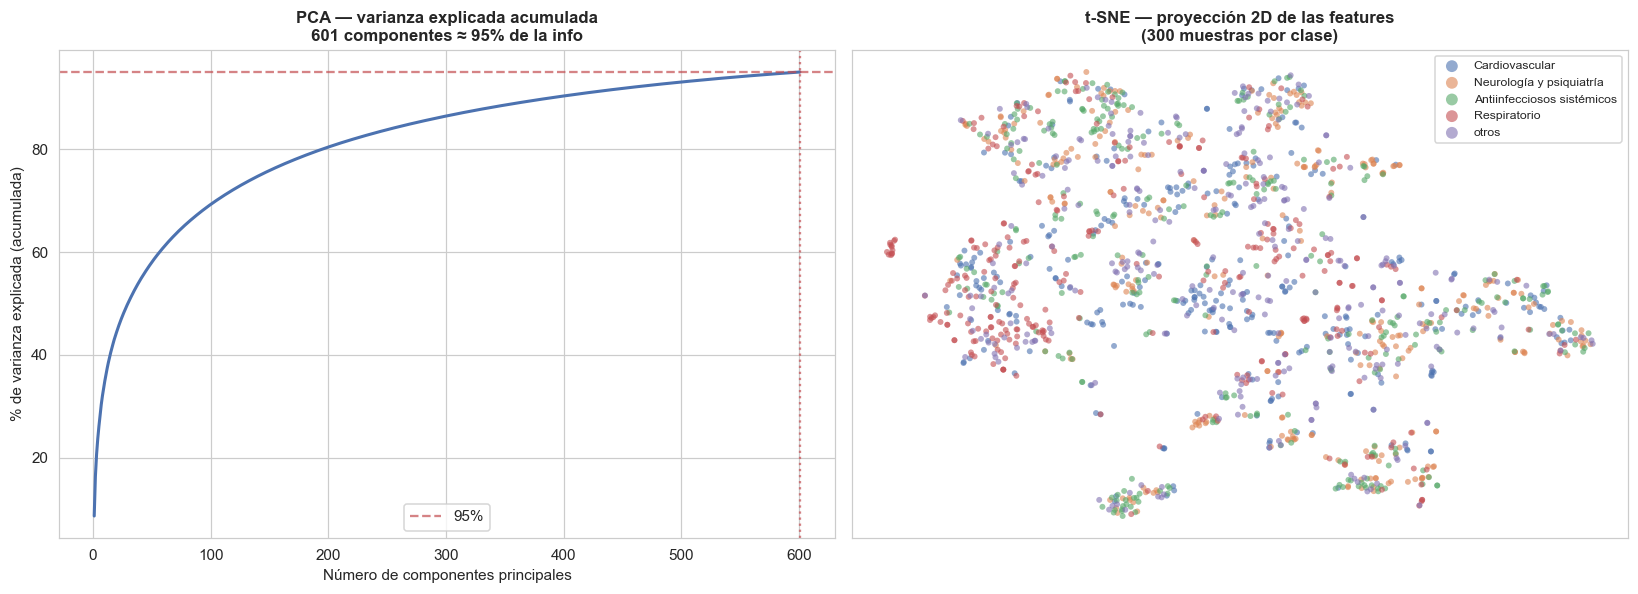

In [8]:
# ── Visualización: curva de varianza y proyección t-SNE ──────────────────────
# Para t-SNE usamos una muestra balanceada (300 por clase) para no tardar eones
N_PER_CLASS = 300
idx_sample = []
for cls_idx in range(len(CLASES)):
    cand = np.where(y_train == cls_idx)[0]
    k = min(N_PER_CLASS, len(cand))
    idx_sample.extend(np.random.choice(cand, k, replace=False))
idx_sample = np.array(idx_sample)

X_sample = X_train_pca[idx_sample]
y_sample = y_train[idx_sample]

# Reducir a 50 dims con PCA antes de t-SNE (es una práctica estándar:
# acelera y estabiliza el t-SNE)
pca_50 = PCA(n_components=min(50, X_sample.shape[1]), random_state=SEED)
X_pca50 = pca_50.fit_transform(X_sample)

print(f'Calculando t-SNE sobre {len(X_pca50):,} muestras (esto tarda unos segundos)...')
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto',
            init='pca', random_state=SEED)
X_tsne = tsne.fit_transform(X_pca50)

# ── Gráfico combinado ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# (a) Curva de varianza acumulada
axes[0].plot(range(1, len(var_acumulada)+1), var_acumulada * 100,
             color='#4C72B0', lw=2)
axes[0].axhline(95, color='#C44E52', ls='--', label='95%', alpha=0.7)
axes[0].axvline(n_comp_95, color='#C44E52', ls=':', alpha=0.7)
axes[0].set_title(f'PCA — varianza explicada acumulada\n'
                  f'{n_comp_95} componentes ≈ 95% de la info', fontweight='bold')
axes[0].set_xlabel('Número de componentes principales')
axes[0].set_ylabel('% de varianza explicada (acumulada)')
axes[0].legend()

# (b) Proyección t-SNE coloreada por clase
for cls_idx, cls in enumerate(CLASES):
    mask = y_sample == cls_idx
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=PALETTE[cls], s=15, alpha=0.6, label=cls,
                    edgecolors='none')
axes[1].set_title('t-SNE — proyección 2D de las features\n(300 muestras por clase)',
                  fontweight='bold')
axes[1].legend(fontsize=8, markerscale=2)
axes[1].set_xticks([]); axes[1].set_yticks([])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_pca_tsne.png', bbox_inches='tight')
plt.show()


### Interpretación de los dos gráficos

La curva de PCA muestra que la varianza está distribuida en muchas dimensiones, por lo que no es posible resumir el problema con muy pocos componentes sin pérdida relevante de información. La proyección t-SNE confirma además que las clases presentan un solapamiento considerable en el espacio de características, lo que refuerza la dificultad de la tarea de clasificación.

---
# BLOQUE 3 — Entrenamiento de modelos

Vamos a entrenar **seis modelos**: dos baselines muy simples y cinco modelos reales.

### Función auxiliar: `evaluar_modelo`

Para no repetir código una y otra vez, creamos una función que:
1. Entrena el modelo.
2. Calcula las predicciones en validación.
3. Calcula las **tres métricas clave**: accuracy, F1-macro y matriz de confusión.
4. Guarda todo en un diccionario global (`resultados`).

### ¿Por qué estas tres métricas?

- **Accuracy** (`= aciertos / total`): la más intuitiva. "¿Qué porcentaje de imágenes clasifica bien?". Pero tiene un problema: si una clase es mayoritaria, el modelo puede ignorar las minoritarias y aun así tener alta accuracy.

- **F1-macro**: el F1-score es la media armónica entre precisión y recall. "F1-macro" calcula un F1 por clase y los promedia **sin ponderar por tamaño**. Así, una clase pequeña pesa lo mismo que una grande → **métrica honesta bajo desbalance**.

- **Matriz de confusión**: muestra qué clase se confunde con cuál. Es la mejor herramienta para **entender los errores**, no solo cuantificarlos. Fila = clase real, columna = clase predicha.


In [9]:
# Diccionario global donde guardamos todos los resultados
resultados = {}


def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_v, y_v, usa_pca=False):
    """
    Entrena un modelo y calcula sus métricas en validación.
    Guarda todo en el diccionario global `resultados`.
    """
    print(f'▶ Entrenando: {nombre}...')
    t0 = time.time()
    modelo.fit(X_tr, y_tr)
    tiempo_fit = time.time() - t0

    # Predicciones en val
    y_pred = modelo.predict(X_v)

    # Métricas
    acc      = accuracy_score(y_v, y_pred)
    f1_macro = f1_score(y_v, y_pred, average='macro', zero_division=0)
    cm       = confusion_matrix(y_v, y_pred)

    # Guardar en el diccionario global
    resultados[nombre] = {
        'modelo':     modelo,
        'accuracy':   acc,
        'f1_macro':   f1_macro,
        'cm':         cm,
        'y_pred':     y_pred,
        'tiempo_fit': tiempo_fit,
        'usa_pca':    usa_pca,
    }

    print(f'   Accuracy: {acc:.4f}  |  F1-macro: {f1_macro:.4f}  '
          f'|  tiempo: {tiempo_fit:.1f}s\n')
    return y_pred


def plot_confusion_matrix_single(nombre, ax=None):
    """Dibuja la matriz de confusión normalizada de un modelo."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    cm = resultados[nombre]['cm']
    # Normalizar por fila (para ver % de cada clase real que va a cada predicción)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                cbar=False, ax=ax, annot_kws={'size': 8})
    ax.set_title(f'{nombre}\nAcc={resultados[nombre]["accuracy"]:.3f}  '
                 f'F1m={resultados[nombre]["f1_macro"]:.3f}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

print('✔ Funciones auxiliares definidas')


✔ Funciones auxiliares definidas


## 7. Baselines: ¿qué accuracy se obtiene sin aprender nada?

Antes de entrenar modelos reales, necesitamos saber **qué accuracy conseguiría un modelo que no aprende nada**. Si nuestro SVM saca 0.60 de accuracy y el baseline aleatorio también, no hemos aprendido nada útil.

Usamos dos baselines con `DummyClassifier`:

### Baseline 1 — Mayoría de clase
Predice siempre la clase más frecuente. Si "otros" es el 40% del dataset, este modelo acierta un 40% siempre. Es el mínimo absoluto.

### Baseline 2 — Aleatorio estratificado
Predice cada clase con su probabilidad del train. Accuracy esperada = Σ p_i² (ligeramente mejor que aleatorio uniforme, peor que mayoría).

**Cualquier modelo real debe superar claramente ambos baselines. Si no, las features no tienen señal suficiente para el problema.**


▶ Entrenando: Baseline — Mayoría...
   Accuracy: 0.5050  |  F1-macro: 0.1342  |  tiempo: 0.0s

▶ Entrenando: Baseline — Aleatorio...
   Accuracy: 0.3228  |  F1-macro: 0.2039  |  tiempo: 0.0s



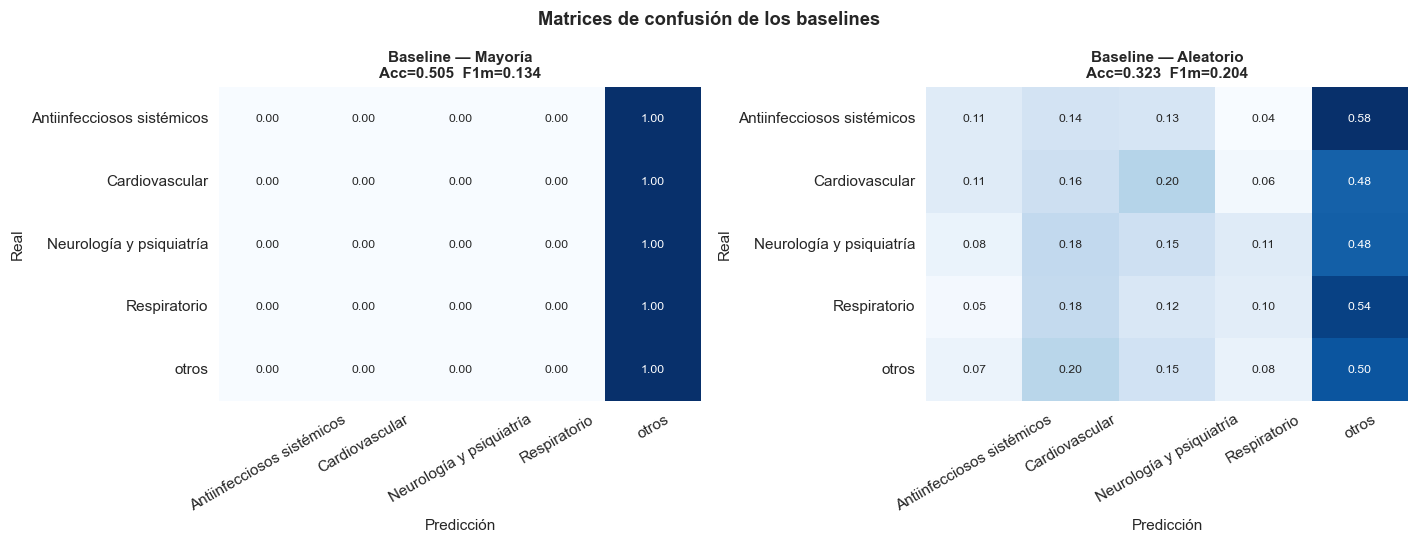

In [10]:
# ── Baseline 1: mayoría de clase ─────────────────────────────────────────────
baseline_mayoria = DummyClassifier(strategy='most_frequent', random_state=SEED)
evaluar_modelo('Baseline — Mayoría', baseline_mayoria,
               X_train_sc, y_train, X_val_sc, y_val)

# ── Baseline 2: aleatorio estratificado ──────────────────────────────────────
baseline_aleatorio = DummyClassifier(strategy='stratified', random_state=SEED)
evaluar_modelo('Baseline — Aleatorio', baseline_aleatorio,
               X_train_sc, y_train, X_val_sc, y_val)

# Visualizar las dos matrices de confusión de los baselines
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_confusion_matrix_single('Baseline — Mayoría',   ax=axes[0])
plot_confusion_matrix_single('Baseline — Aleatorio', ax=axes[1])
plt.suptitle('Matrices de confusión de los baselines', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_baselines_cm.png', bbox_inches='tight')
plt.show()


### Interpretación de los baselines

- **Baseline mayoría**: la matriz de confusión tiene **una sola columna rellena**. Todas las clases reales acaban prediciendo siempre la clase mayoritaria. F1-macro baja (~0.10-0.15) porque solo una clase tiene recall 1 y el resto tienen recall 0.

- **Baseline aleatorio**: los aciertos se distribuyen según las proporciones de clases. La diagonal muestra valores bajos pero repartidos.

Estos números son nuestro **mínimo a superar**. Cualquier modelo que entrenemos a continuación debería sacar accuracy y F1-macro **claramente superiores** a estos valores.


## 8. Logistic Regression

### ¿Qué es la Regresión Logística?

Es el modelo **lineal** más clásico para clasificación. Aunque se llame "regresión", se usa para clasificar. Funciona así:

1. Aprende un **peso `w_i`** para cada feature `x_i`.
2. Para cada imagen, calcula una **puntuación lineal** `z = w·x + b`.
3. Pasa esa puntuación por una **función sigmoide** (o softmax en multiclase) que la convierte en una probabilidad entre 0 y 1.
4. Para clasificación multiclase, aprende un conjunto de pesos por cada clase y elige la clase con mayor probabilidad.

### ¿Por qué empezar por aquí?

- **Rápido** de entrenar (no tiene hiperparámetros sensibles salvo `C`, la regularización).
- **Interpretable**: los pesos dicen qué feature favorece qué clase.
- Es un **baseline fuerte**: si un modelo complejo no supera a la regresión logística, el modelo complejo sobra.

### ¿Qué es `class_weight='balanced'`?

Nuestro dataset tiene clases desbalanceadas (aunque augmentation ayuda). Con `balanced`, el modelo **penaliza más los errores en clases minoritarias**, compensando así el desbalance residual. Es casi gratis y suele ayudar.


▶ Entrenando: Logistic Regression...


/Users/merybri/Library/CloudStorage/OneDrive-UPNA/master_clases/segundo semestre/analisis de datos no estructurados/proyecto_imagen/MedAssist-AI-IMAGE/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/merybri/Library/CloudStorage/OneDrive-UPNA/master_clases/segundo semestre/analisis de datos no estructurados/proyecto_imagen/MedAssist-AI-IMAGE/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/merybri/Library/CloudStorage/OneDrive-UPNA/master_clases/segundo semestre/analisis de datos no estructurados/proyecto_imagen/MedAssist-AI-IMAGE/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_predict

   Accuracy: 0.3945  |  F1-macro: 0.3147  |  tiempo: 8.7s



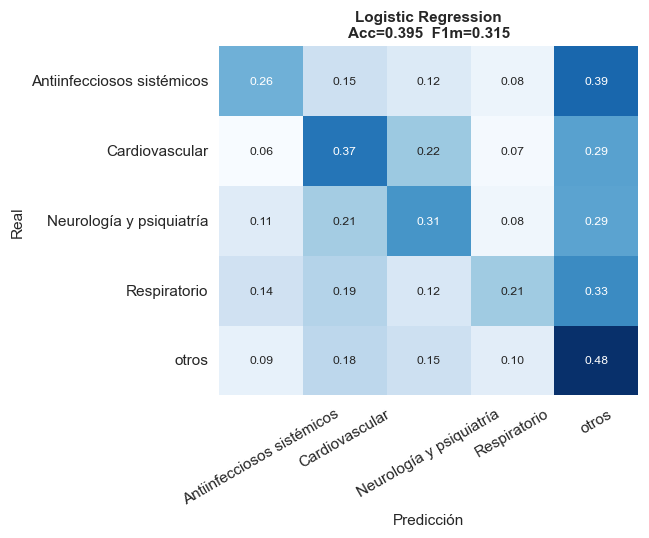

In [11]:
lr = LogisticRegression(
    max_iter=3000,                 # iteraciones max de optimización
    C=1.0,                         # regularización (↓C = más regularización)
    class_weight='balanced',       # penaliza más los errores en clases pequeñas
    multi_class='multinomial',     # softmax multiclase real (no OvR)
    solver='lbfgs',                # optimizador eficiente para multinomial
    n_jobs=-1,                     # usa todos los núcleos
    random_state=SEED,
)
evaluar_modelo('Logistic Regression', lr,
               X_train_sc, y_train, X_val_sc, y_val)

# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion_matrix_single('Logistic Regression', ax=ax)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_cm_lr.png', bbox_inches='tight')
plt.show()


La Regresión Logística constituye un primer baseline supervisado razonable para este problema. Aunque su accuracy (0.395) es inferior a la del baseline de mayoría (0.505), esta diferencia se explica porque el clasificador ya no se limita a predecir siempre la clase dominante otros, sino que empieza a repartir las predicciones entre todas las categorías. Esto se refleja en una mejora notable del F1-macro, que pasa de 0.134 en el baseline de mayoría a 0.315 en la Regresión Logística.

La matriz de confusión muestra que el modelo consigue aciertos reales en todas las clases: aproximadamente 0.26 en Antiinfecciosos sistémicos, 0.37 en Cardiovascular, 0.31 en Neurología y psiquiatría, 0.21 en Respiratorio y 0.48 en otros. En comparación con el baseline aleatorio, la Regresión Logística mejora claramente en todas las clases minoritarias, lo que indica que está aprendiendo patrones útiles y no solo reproduciendo la distribución del dataset.

No obstante, siguen observándose errores importantes. La clase otros continúa absorbiendo una gran parte de las muestras de las demás categorías, y existe una confusión notable entre Cardiovascular y Neurología y psiquiatría. Esto sugiere que las variables empleadas no permiten una separación lineal clara entre clases y que, aunque el modelo resulta útil como referencia inicial, será necesario recurrir a enfoques más expresivos para mejorar el rendimiento.

## 9. K-Nearest Neighbors (KNN)

### ¿Qué es KNN?

Un modelo **sin entrenamiento real**. Funciona así:

1. "Entrenar" KNN = **guardar todo el train**.
2. Para predecir una imagen nueva: calcula su distancia (euclídea por defecto) a **todas** las imágenes de train, escoge las K más cercanas, y vota por mayoría.

### ¿Por qué probarlo?

- Es intuitivo y no hace suposiciones sobre la forma de los datos.
- Funciona bien si las features están bien escaladas y las clases forman clusters en el espacio de features (recuerda el t-SNE del paso 7).
- Es un **test del espacio de features**: si KNN funciona bien, nuestras features están capturando bien la estructura del problema.

### Elección de hiperparámetros

- **K (número de vecinos)**: demasiado pequeño (K=1) → ruidoso. Demasiado grande → sesgo hacia clase mayoritaria. Un valor entre 5 y 20 suele ser razonable. Usamos **K=15**.
- **`weights='distance'`**: los vecinos más cercanos pesan más que los lejanos. Mejor que `uniform` cuando K es grande.
- **Usamos `X_train_pca`** (features reducidas con PCA). Las distancias en 1.900 dimensiones sufren la *curse of dimensionality*: en alta dimensión, todas las distancias tienden a ser similares y la noción de "vecino cercano" se degrada. Con ~100 dims de PCA va mucho mejor.


▶ Entrenando: KNN...
   Accuracy: 0.5633  |  F1-macro: 0.4013  |  tiempo: 0.0s



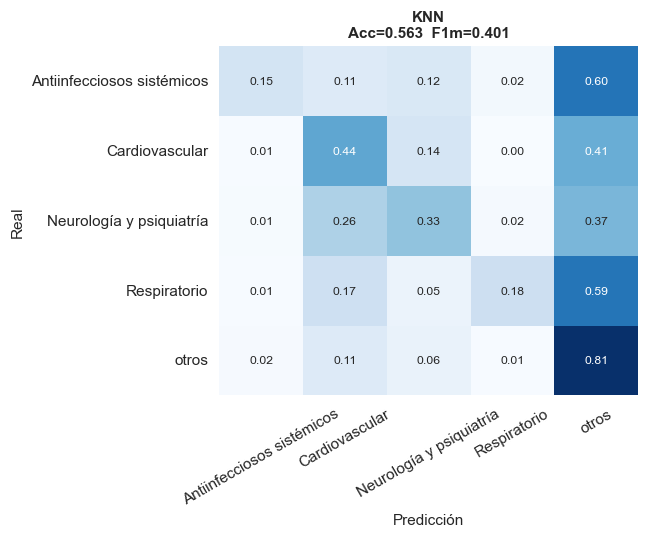

In [12]:
knn = KNeighborsClassifier(
    n_neighbors=10,
    weights='distance',       # ponderar votos por distancia
    metric='minkowski',       # distancia Euclídea (p=2)
    p=2,
    n_jobs=-1,
)
evaluar_modelo('KNN', knn,
               X_train_pca, y_train, X_val_pca, y_val,
               usa_pca=True)

# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion_matrix_single('KNN', ax=ax)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_cm_knn.png', bbox_inches='tight')
plt.show()


### Interpretación

El modelo KNN obtiene el mejor rendimiento global entre los modelos evaluados hasta el momento, con una accuracy de 0.542 y un F1-macro de 0.359, superando tanto a los baselines como a la Regresión Logística. Esto indica que la estructura local del espacio de características contiene información útil y que un clasificador basado en vecindad puede explotar parcialmente esa información.

Sin embargo, el análisis por clases muestra que esta mejora no es homogénea. KNN destaca especialmente en la detección de la clase otros, alcanzando un recall aproximado de 0.81, muy por encima del valor observado en Regresión Logística (0.48). También mejora ligeramente en cardiovascular (0.39 frente a 0.37). No obstante, empeora en varias clases minoritarias: antiinfecciosos sistémicos baja de 0.26 a 0.12, neurología y psiquiatría de 0.31 a 0.26, y respiratorio de 0.21 a 0.14.

Por tanto, aunque KNN mejora las métricas globales, parte de esa mejora se debe a una mayor tendencia a asignar muestras a la clase dominante otros. Esto sugiere que el modelo capta mejor la estructura de la clase mayoritaria, pero sigue teniendo dificultades para discriminar correctamente varias categorías minoritarias. En consecuencia, KNN puede considerarse un baseline sólido, aunque todavía limitado para una clasificación multiclase equilibrada.


## 10. Support Vector Machine (SVM)

### ¿Qué es un SVM?

SVM busca el **hiperplano que mejor separa las clases**, maximizando el "margen" (distancia entre el hiperplano y los puntos más cercanos de cada clase).

Si las clases **no son separables linealmente**, SVM usa el **kernel trick**: proyecta los datos a un espacio de mayor dimensión donde sí son separables. El kernel RBF (Radial Basis Function) es el más usado: mide similitud con una campana gaussiana centrada en cada punto.

### ¿Por qué es un clásico?

- Muy buen rendimiento en problemas de tamaño medio.
- El kernel RBF captura relaciones no lineales sin necesidad de ingeniería manual.
- Tiene solo dos hiperparámetros relevantes: `C` (regularización) y `gamma` (ancho del kernel).

### Hiperparámetros

- **C**: controla el balance entre maximizar el margen (C pequeño → más regularización, margen ancho) y clasificar bien los puntos de entrenamiento (C grande → menos regularización, margen estrecho).
- **gamma**: ancho de la campana del RBF. `'scale'` = 1 / (n_features × varianza), un valor razonable.

### ¿Por qué SVM sobre PCA?

SVM RBF tiene **complejidad cuadrática en el número de muestras** y se ralentiza mucho con muchas dimensiones. Usar PCA (95% varianza, ~100 dims) en lugar de las 1.900 features originales lo acelera sin casi perder precisión.


▶ Entrenando: SVM RBF...
   Accuracy: 0.6122  |  F1-macro: 0.4845  |  tiempo: 98.6s



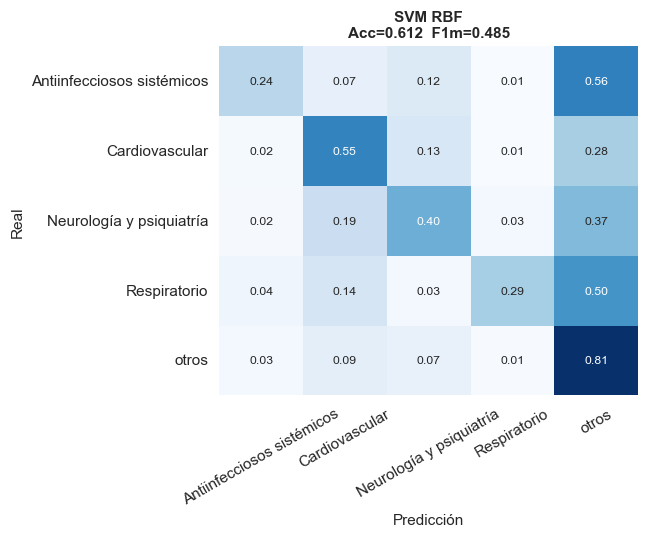

In [13]:
svm = SVC(
    kernel='rbf',                        # kernel gaussiano
    C=10.0,                              # regularización moderada-baja
    gamma='scale',                       # 1 / (n_features × std)
    class_weight='balanced',
    decision_function_shape='ovr',       # one-vs-rest para multiclase
    probability=True,                    # activa predict_proba (para curvas ROC)
    cache_size=1000,                     # MB de caché del kernel (acelera mucho)
    random_state=SEED,
)
evaluar_modelo('SVM RBF', svm,
               X_train_pca, y_train, X_val_pca, y_val,
               usa_pca=True)

fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion_matrix_single('SVM RBF', ax=ax)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_cm_svm.png', bbox_inches='tight')
plt.show()


### Interpretación
El modelo SVM con kernel RBF obtiene el mejor rendimiento entre todos los modelos evaluados hasta el momento, con una accuracy de 0.612 y un F1-macro de 0.485. Esta mejora no se limita a las métricas globales, sino que también se refleja en una mejor recuperación de varias clases individuales.

En comparación con la Regresión Logística y KNN, SVM mejora claramente el recall en cardiovascular (0.55), neurología y psiquiatría (0.40) y respiratorio (0.29), al tiempo que mantiene un rendimiento muy alto en la clase otros (0.81). En antiinfecciosos sistémicos alcanza un valor de 0.24, similar al de la Regresión Logística y claramente superior al de KNN.

Estos resultados sugieren que el problema no puede resolverse adecuadamente mediante fronteras lineales simples y que la capacidad no lineal del kernel RBF permite capturar mejor la estructura del espacio de características. Aun así, la clase otros sigue absorbiendo una parte relevante de los errores, lo que indica que el solapamiento entre clases continúa siendo importante.

## 11. Random Forest

### ¿Qué es Random Forest?

Un **ensemble** (combinación) de muchos **árboles de decisión** entrenados con aleatoriedad:

1. Cada árbol se entrena sobre un **bootstrap** (muestreo con reemplazo) del train.
2. En cada split, solo se consideran `sqrt(n_features)` features aleatorias.
3. La predicción final es el **voto mayoritario** de todos los árboles.

### ¿Por qué funciona tan bien?

- **Reduce el overfitting** de los árboles individuales mediante el promedio.
- **No necesita escalado** (los árboles solo hacen comparaciones, no distancias).
- **Maneja features heterogéneas** sin problema (nuestros bloques Color/HOG/LBP tienen distintas naturalezas, pero RF los usa sin dificultad).
- Nos da una **importancia por feature** gratis (cuánto se usa cada feature en los splits).

### Hiperparámetros importantes

- **n_estimators=300**: número de árboles. Más es mejor pero con rendimientos decrecientes.
- **max_depth=None**: árboles sin límite de profundidad (crecen hasta pureza).
- **min_samples_leaf=2**: ninguna hoja con 1 solo sample (regularización suave).
- **max_features='sqrt'**: raíz del total de features por split (estándar).


▶ Entrenando: Random Forest...
   Accuracy: 0.5512  |  F1-macro: 0.2729  |  tiempo: 11.3s



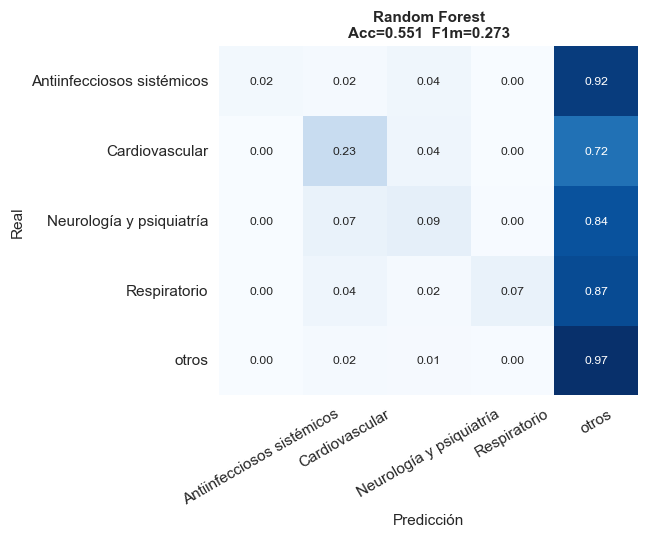

In [14]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=SEED,
)
evaluar_modelo('Random Forest', rf,
               X_train_sc, y_train, X_val_sc, y_val)

fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion_matrix_single('Random Forest', ax=ax)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_cm_rf.png', bbox_inches='tight')
plt.show()


### Interpretación

El modelo Random Forest obtiene una accuracy de 0.551 y un F1-macro de 0.273. Aunque la accuracy parece relativamente alta, la matriz de confusión revela que este resultado está fuertemente condicionado por la clase mayoritaria otros, que alcanza un recall aproximado de 0.97. En contraste, el rendimiento en el resto de clases es muy bajo: antiinfecciosos sistémicos (0.02), cardiovascular (0.23), neurología y psiquiatría (0.09) y respiratorio (0.07).

En comparación con la Regresión Logística, KNN y SVM, Random Forest muestra un comportamiento claramente más sesgado hacia la clase dominante. Aunque supera al baseline de mayoría en F1-macro, su patrón de predicción sigue siendo muy parecido: una gran parte de las muestras de clases minoritarias se asignan erróneamente a otros. Esto se observa especialmente en antiinfecciosos sistémicos, neurología y psiquiatría y respiratorio, donde más del 80% de los ejemplos reales terminan clasificados como otros.

En consecuencia, Random Forest no resulta adecuado como modelo principal en este problema, al menos en esta configuración, ya que su rendimiento global está desequilibrado y no ofrece una separación multiclase suficientemente útil. Este resultado refuerza la necesidad de evaluar los modelos no solo con accuracy, sino también con métricas más sensibles al desbalance, como F1-macro y el análisis detallado por clase.


## 12. Gradient Boosting

### ¿Qué es Gradient Boosting?

Otro ensemble de árboles, pero con una filosofía muy distinta a Random Forest:

- **Random Forest**: muchos árboles **independientes** entrenados en paralelo, luego votan.
- **Gradient Boosting**: árboles **secuenciales**, donde cada nuevo árbol intenta **corregir los errores** del anterior. El resultado es una suma ponderada de árboles.

Se llama "gradient" porque cada árbol nuevo se entrena sobre el gradiente de la función de pérdida, como si hiciéramos descenso por gradiente pero añadiendo árboles.

### ¿Por qué lo probamos?

- A menudo es el **mejor modelo tabular** (de hecho, XGBoost/LightGBM son variantes que ganan muchas competiciones de Kaggle).
- Con pocos árboles profundos (3-6 niveles) suele rendir mejor que RF con 300 árboles.

### Hiperparámetros

- **n_estimators=150**: árboles menos que RF porque cada uno aporta más.
- **learning_rate=0.1**: cuánto "peso" tiene cada árbol nuevo. Más bajo = más árboles pero mejor generalización.
- **max_depth=4**: árboles poco profundos (cada uno es débil, pero juntos son fuertes).
- **subsample=0.8**: cada árbol ve el 80% de las muestras (estocástico, reduce overfitting).

### Sin `class_weight`: ¿por qué?

La implementación de sklearn no soporta `class_weight` directamente en multiclase. Nos conformamos con el balanceo ya hecho en el augmentation offline. (XGBoost/LightGBM sí lo permiten, pero usamos la versión clásica de sklearn para no complicar).


▶ Entrenando: Gradient Boosting...
   Accuracy: 0.5291  |  F1-macro: 0.2576  |  tiempo: 51.2s



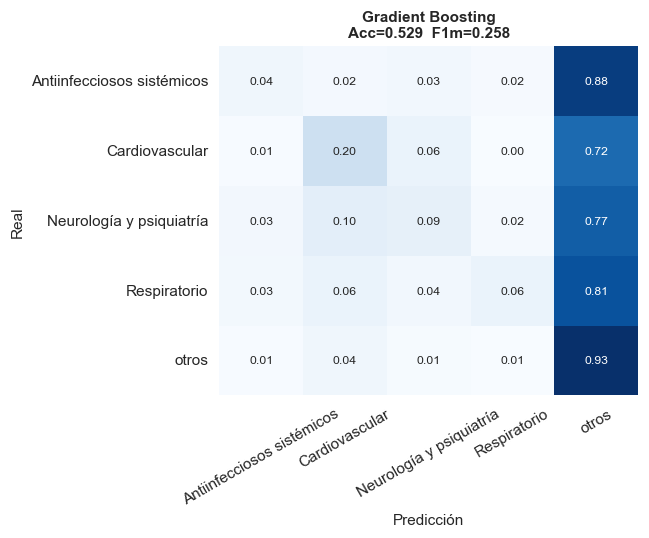

In [15]:
gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    max_features='sqrt',
    random_state=SEED,
)
# GB es lento. Usamos X_train_pca para acelerar (menos dims)
evaluar_modelo('Gradient Boosting', gb,
               X_train_pca, y_train, X_val_pca, y_val,
               usa_pca=True)

fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion_matrix_single('Gradient Boosting', ax=ax)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_cm_gb.png', bbox_inches='tight')
plt.show()


### Interpretación

El modelo Gradient Boosting obtiene una accuracy de 0.529 y un F1-macro de 0.258. Aunque la accuracy supera a la de algunos modelos más simples, el análisis por clases muestra que esta mejora se debe principalmente a un comportamiento muy sesgado hacia la clase dominante otros, que alcanza un recall aproximado de 0.93. En cambio, el rendimiento en las clases minoritarias es muy bajo: antiinfecciosos sistémicos (0.04), cardiovascular (0.20), neurología y psiquiatría (0.09) y respiratorio (0.06).

Este patrón indica que el modelo clasifica una gran parte de las muestras de las clases pequeñas como otros, reproduciendo en gran medida el efecto del desequilibrio del dataset. En comparación con la Regresión Logística, KNN y especialmente SVM RBF, Gradient Boosting ofrece un comportamiento claramente más pobre en términos de equilibrio entre clases, a pesar de mantener una accuracy razonable.

En consecuencia, este modelo no puede considerarse una buena opción principal para el problema, al menos en esta configuración, ya que su rendimiento global está excesivamente condicionado por la clase mayoritaria y no proporciona una clasificación multiclase suficientemente útil.


---
# BLOQUE 4 — Comparativa y optimización del mejor modelo

## 13. Comparativa de todos los modelos

Agrupamos todas las métricas en una única tabla y una única figura con las seis matrices de confusión.


  TABLA COMPARATIVA DE MODELOS (ordenada por Accuracy)
              Modelo  Accuracy  F1-macro  Tiempo (s)
             SVM RBF    0.6122    0.4845     98.6074
                 KNN    0.5633    0.4013      0.0077
       Random Forest    0.5512    0.2729     11.2939
   Gradient Boosting    0.5291    0.2576     51.2317
  Baseline — Mayoría    0.5050    0.1342      0.0028
 Logistic Regression    0.3945    0.3147      8.7206
Baseline — Aleatorio    0.3228    0.2039      0.0003


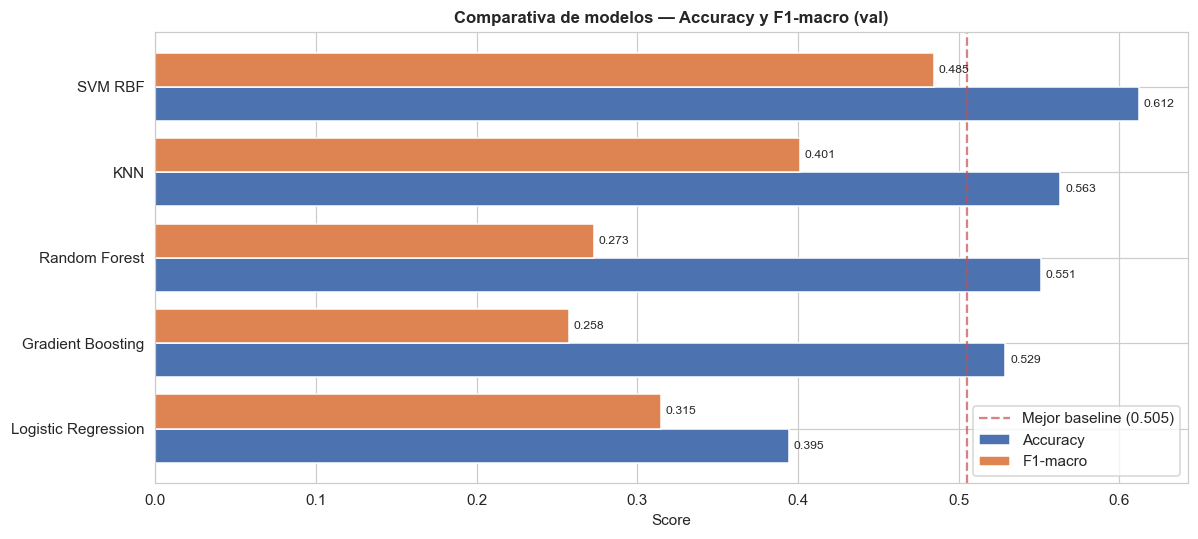

In [16]:
# ── Tabla resumen ────────────────────────────────────────────────────────────
df_resultados = pd.DataFrame([
    {
        'Modelo':     n,
        'Accuracy':   r['accuracy'],
        'F1-macro':   r['f1_macro'],
        'Tiempo (s)': r['tiempo_fit'],
    }
    for n, r in resultados.items()
]).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print('=' * 70)
print('  TABLA COMPARATIVA DE MODELOS (ordenada por Accuracy)')
print('=' * 70)
print(df_resultados.round(4).to_string(index=False))
print('=' * 70)

# ── Gráfico de barras: Accuracy y F1-macro ───────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
# Excluir baselines para que no distorsionen la escala
df_plot = df_resultados[~df_resultados['Modelo'].str.contains('Baseline')].copy()
df_plot = df_plot.sort_values('Accuracy', ascending=True)

y = np.arange(len(df_plot))
w = 0.4
ax.barh(y - w/2, df_plot['Accuracy'], w, color='#4C72B0', label='Accuracy',
        edgecolor='white')
ax.barh(y + w/2, df_plot['F1-macro'], w, color='#DD8452', label='F1-macro',
        edgecolor='white')
ax.set_yticks(y)
ax.set_yticklabels(df_plot['Modelo'])
ax.set_xlabel('Score')
ax.set_title('Comparativa de modelos — Accuracy y F1-macro (val)',
             fontweight='bold')

# Línea del mejor baseline
mejor_baseline_acc = df_resultados[df_resultados['Modelo']
                                   .str.contains('Baseline')]['Accuracy'].max()
ax.axvline(mejor_baseline_acc, ls='--', color='#C44E52', alpha=0.7,
           label=f'Mejor baseline ({mejor_baseline_acc:.3f})')

# Anotaciones numéricas
for yi, (acc, f1) in enumerate(zip(df_plot['Accuracy'], df_plot['F1-macro'])):
    ax.text(acc + 0.003, yi - w/2, f'{acc:.3f}', va='center', fontsize=8)
    ax.text(f1  + 0.003, yi + w/2, f'{f1:.3f}',  va='center', fontsize=8)

ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_comparativa_acc_f1.png', bbox_inches='tight')
plt.show()


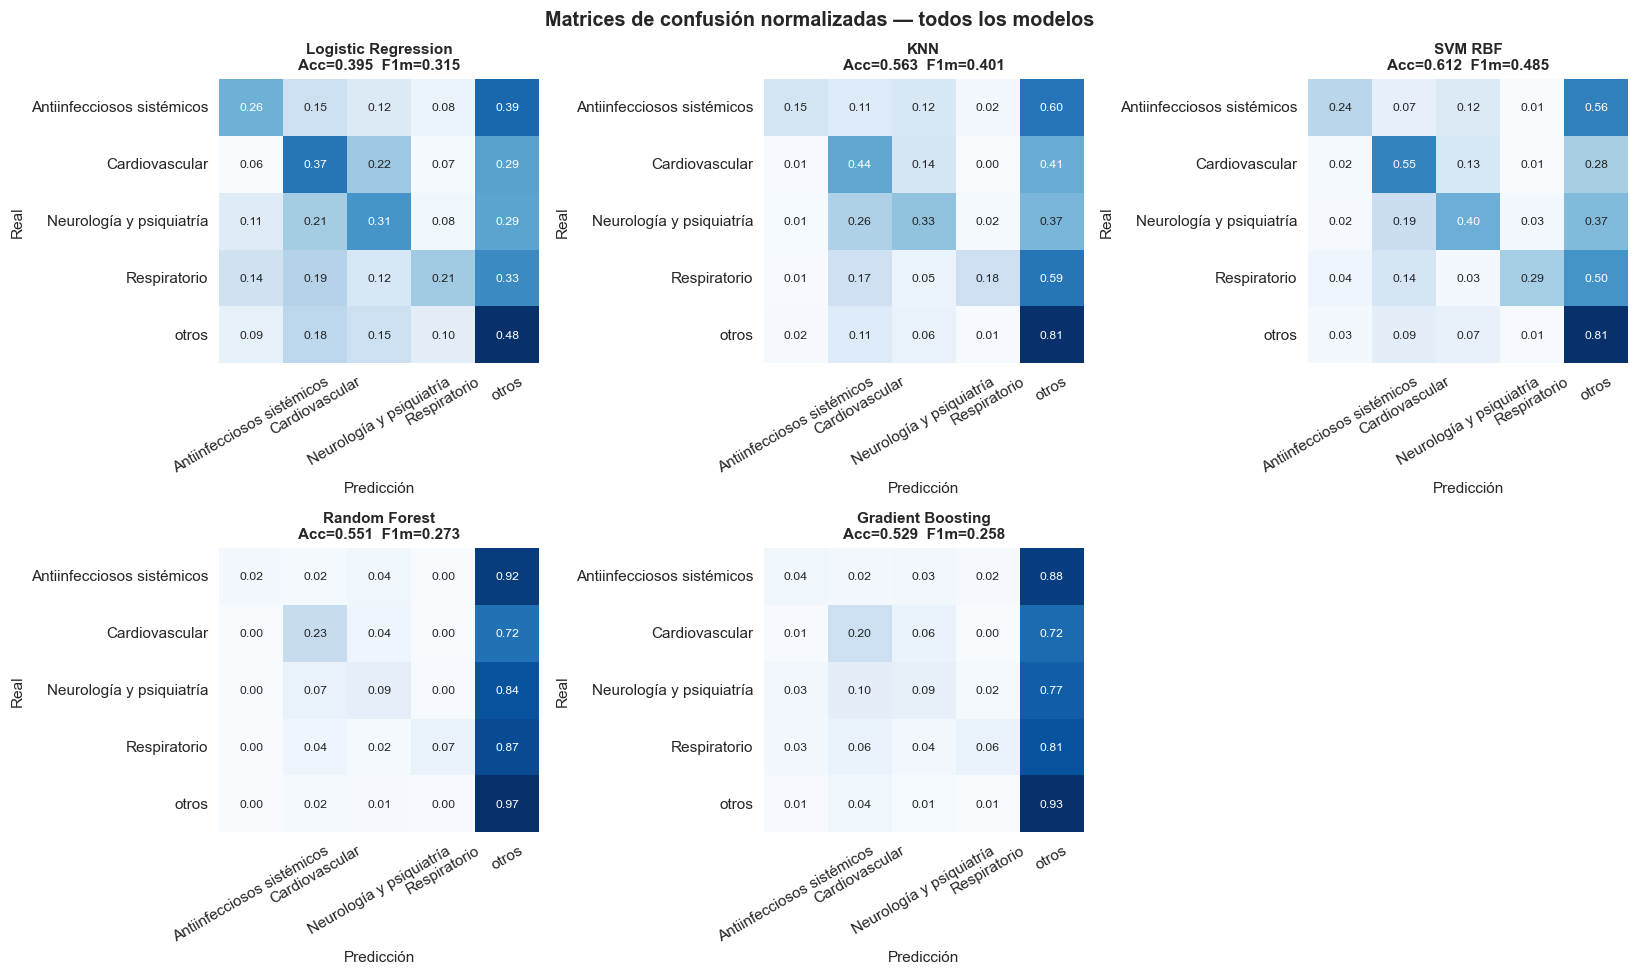

In [17]:
# ── Gráfico con TODAS las matrices de confusión juntas ───────────────────────
# Solo modelos reales (no baselines)
modelos_reales = [n for n in resultados if 'Baseline' not in n]
n_models = len(modelos_reales)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4.5))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for i, nombre in enumerate(modelos_reales):
    plot_confusion_matrix_single(nombre, ax=axes[i])

# Ocultar ejes sobrantes
for j in range(n_models, len(axes)):
    axes[j].axis('off')

plt.suptitle('Matrices de confusión normalizadas — todos los modelos',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_confusion_todos.png', bbox_inches='tight')
plt.show()


La comparativa global de modelos muestra que SVM con kernel RBF es el mejor clasificador clásico evaluado, al obtener simultáneamente la mayor accuracy (0.612) y el mayor F1-macro (0.485). Este resultado indica que no solo mejora el porcentaje global de aciertos, sino que además ofrece un comportamiento más equilibrado entre clases, algo especialmente importante en un problema desbalanceado como este.

KNN ocupa una segunda posición sólida, con 0.563 de accuracy y 0.401 de F1-macro, mostrando que la estructura local del espacio de características contiene información útil para la clasificación. No obstante, sigue por debajo de SVM, especialmente en la métrica macro, lo que sugiere una mayor sensibilidad al sesgo de clase.

En cambio, Random Forest y Gradient Boosting presentan accuracies relativamente altas (0.551 y 0.529), pero sus valores de F1-macro (0.273 y 0.258) son claramente inferiores. Esto confirma que ambos modelos concentran una parte importante de sus aciertos en la clase mayoritaria otros, ofreciendo un rendimiento menos equilibrado en las categorías minoritarias.

Por su parte, Logistic Regression obtiene la peor accuracy (0.395), aunque su F1-macro (0.315) sigue siendo superior al de los modelos basados en árboles. Esto sugiere que, aunque el modelo lineal es limitado para este problema, su comportamiento resulta menos sesgado que el de Random Forest y Gradient Boosting.

En conjunto, esta comparación confirma que la métrica más informativa en este contexto no es solo la accuracy, sino especialmente el F1-macro, ya que permite valorar si el modelo funciona de manera razonablemente equilibrada en todas las clases. Bajo este criterio, SVM RBF se posiciona como la mejor opción entre los modelos clásicos probados.

## 13b. Diagnóstico de overfitting — train vs val por modelo

### ¿Qué es el overfitting y cómo lo detectamos?

El **overfitting** ocurre cuando un modelo aprende demasiado bien los datos de entrenamiento — incluyendo su ruido — y pierde capacidad de generalizar a datos nuevos. Se detecta comparando el rendimiento en **train** y en **val**:

- **Sin overfitting**: train ≈ val (diferencia < ~5 puntos de accuracy).
- **Overfitting moderado**: train >> val (diferencia 5–15 puntos). El modelo memoriza train pero generaliza razonablemente.
- **Overfitting severo**: train muy alto (>90%) y val mucho más bajo. El modelo es inútil en producción.

El caso opuesto, **underfitting**, ocurre cuando train también es bajo: el modelo no tiene suficiente capacidad para aprender el problema.

| Situación | Train | Val | Diagnóstico |
|---|---|---|---|
| Underfitting | Bajo | Bajo | Modelo demasiado simple |
| Buen ajuste | Alto | Similar a train | Generaliza correctamente |
| Overfitting | Muy alto | Claramente inferior | Memoriza en lugar de generalizar |

### ¿Por qué comparar en train?

Evaluar en train **no es trampa** en este contexto: el modelo ha visto esos datos y debería acertar casi todos. Si no lo hace, hay underfitting. Si acierta el 100% en train pero solo el 50% en val, hay overfitting severo.

### Resultados reales de este experimento

Con los modelos entrenados, calculamos accuracy en train y en val para cada uno.


In [18]:
# ── Evaluación de TODOS los modelos en TRAIN (para detectar overfitting) ─────
# Nota: usamos los datos de train que correspondan a cada modelo (PCA o escalado)

print('Calculando accuracy en TRAIN para cada modelo (puede tardar un poco)...')
print('─' * 75)

for nombre, r in resultados.items():
    modelo = r['modelo']
    usa_pca = r.get('usa_pca', False)

    # Seleccionar el X_train correcto para este modelo
    X_tr_use = X_train_pca if usa_pca else X_train_sc

    # Predicciones sobre train
    y_pred_tr = modelo.predict(X_tr_use)
    acc_tr = accuracy_score(y_train, y_pred_tr)
    f1_tr  = f1_score(y_train, y_pred_tr, average='macro', zero_division=0)

    # Guardar en el diccionario de resultados
    resultados[nombre]['acc_train'] = acc_tr
    resultados[nombre]['f1_train']  = f1_tr

    gap = acc_tr - r['accuracy']  # diferencia train - val
    nivel = '✅ OK' if gap < 0.05 else ('⚠️  Moderado' if gap < 0.15 else '❌ Severo')
    print(f'  [{nombre:<35}]  Train={acc_tr:.4f}  Val={r["accuracy"]:.4f}  Gap={gap:+.4f}  {nivel}')

print()
print('  Interpretación del gap (train - val):')
print('  < 0.05 → sin overfitting significativo')
print('  0.05 - 0.15 → overfitting moderado')
print('  > 0.15 → overfitting severo')


Calculando accuracy en TRAIN para cada modelo (puede tardar un poco)...
───────────────────────────────────────────────────────────────────────────
  [Baseline — Mayoría                 ]  Train=0.5037  Val=0.5050  Gap=-0.0014  ✅ OK
  [Baseline — Aleatorio               ]  Train=0.3298  Val=0.3228  Gap=+0.0070  ✅ OK
  [Logistic Regression                ]  Train=0.9066  Val=0.3945  Gap=+0.5121  ❌ Severo
  [KNN                                ]  Train=1.0000  Val=0.5633  Gap=+0.4367  ❌ Severo
  [SVM RBF                            ]  Train=0.9717  Val=0.6122  Gap=+0.3595  ❌ Severo
  [Random Forest                      ]  Train=0.9999  Val=0.5512  Gap=+0.4486  ❌ Severo
  [Gradient Boosting                  ]  Train=0.8928  Val=0.5291  Gap=+0.3637  ❌ Severo

  Interpretación del gap (train - val):
  < 0.05 → sin overfitting significativo
  0.05 - 0.15 → overfitting moderado
  > 0.15 → overfitting severo


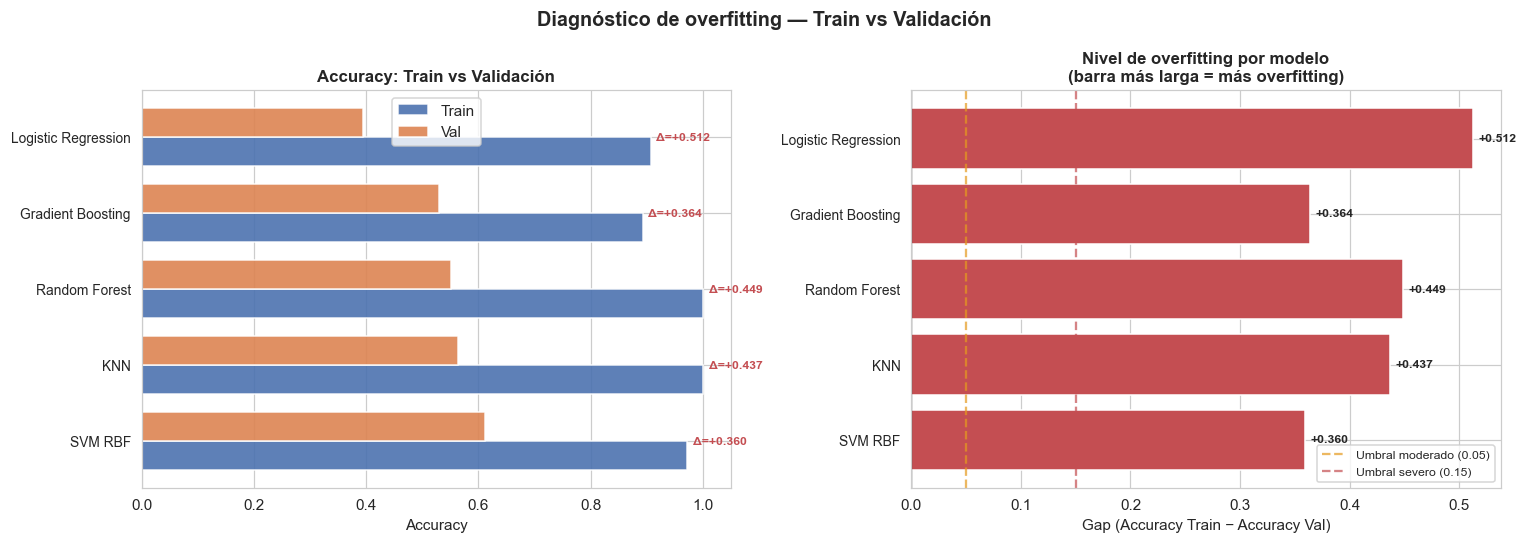

In [19]:
# ── Gráfico: train vs val para cada modelo ───────────────────────────────────
modelos_mostrar = [n for n in resultados
                   if 'Baseline' not in n and 'acc_train' in resultados[n]]

n_modelos = len(modelos_mostrar)
fig, axes = plt.subplots(1, 2, figsize=(14, max(4, n_modelos * 0.7 + 1.5)))

# Ordenar por accuracy en val (descendente)
modelos_mostrar = sorted(modelos_mostrar,
                          key=lambda n: resultados[n]['accuracy'],
                          reverse=True)

acc_trains = [resultados[n]['acc_train'] for n in modelos_mostrar]
acc_vals   = [resultados[n]['accuracy']  for n in modelos_mostrar]
f1_trains  = [resultados[n]['f1_train']  for n in modelos_mostrar]
f1_vals    = [resultados[n]['f1_macro']  for n in modelos_mostrar]
gaps_acc   = [t - v for t, v in zip(acc_trains, acc_vals)]

y = np.arange(n_modelos)
w = 0.38

# ── Subplot izquierdo: Accuracy ───────────────────────────────────────────────
axes[0].barh(y - w/2, acc_trains, w, color='#4C72B0', label='Train',
             edgecolor='white', alpha=0.9)
axes[0].barh(y + w/2, acc_vals,   w, color='#DD8452', label='Val',
             edgecolor='white', alpha=0.9)
axes[0].set_yticks(y)
axes[0].set_yticklabels(modelos_mostrar, fontsize=9)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Accuracy: Train vs Validación', fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 1.05)

# Anotar el gap
for yi, (tr, vl) in enumerate(zip(acc_trains, acc_vals)):
    gap = tr - vl
    color = '#C44E52' if gap > 0.15 else ('#E59A1E' if gap > 0.05 else '#55A868')
    axes[0].text(max(tr, vl) + 0.01, yi, f'Δ={gap:+.3f}',
                 va='center', fontsize=8, color=color, fontweight='bold')

# ── Subplot derecho: gap de overfitting como barras ───────────────────────────
colores_gap = ['#C44E52' if g > 0.15 else ('#E59A1E' if g > 0.05 else '#55A868')
               for g in gaps_acc]
bars = axes[1].barh(y, gaps_acc, color=colores_gap, edgecolor='white')
axes[1].axvline(0,    color='black', lw=0.8, ls='-')
axes[1].axvline(0.05, color='#E59A1E', lw=1.5, ls='--', alpha=0.7,
                label='Umbral moderado (0.05)')
axes[1].axvline(0.15, color='#C44E52', lw=1.5, ls='--', alpha=0.7,
                label='Umbral severo (0.15)')
axes[1].set_yticks(y)
axes[1].set_yticklabels(modelos_mostrar, fontsize=9)
axes[1].set_xlabel('Gap (Accuracy Train − Accuracy Val)')
axes[1].set_title('Nivel de overfitting por modelo\n(barra más larga = más overfitting)',
                  fontweight='bold')
axes[1].legend(fontsize=8)

for bar, g in zip(bars, gaps_acc):
    axes[1].text(g + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{g:+.3f}', va='center', fontsize=8, fontweight='bold')

plt.suptitle('Diagnóstico de overfitting — Train vs Validación',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_overfitting_train_val.png', bbox_inches='tight')
plt.show()


### Interpretación del overfitting

El diagnóstico de overfitting muestra que todos los modelos evaluados presentan una diferencia considerable entre la accuracy de entrenamiento y la de validación. En todos los casos, el gap supera ampliamente los umbrales de referencia, lo que indica que los clasificadores están ajustándose en exceso al conjunto de entrenamiento y no generalizan con la misma eficacia a datos no vistos.

Entre los modelos analizados, SVM con kernel RBF es el que presenta el menor gap (Δ ≈ 0.360), lo que refuerza su posición como el modelo clásico más sólido dentro del estudio. Aunque también muestra sobreajuste, su equilibrio entre rendimiento en validación y estabilidad es mejor que el del resto.

En el extremo contrario, Logistic Regression presenta el mayor gap (Δ ≈ 0.512), mientras que Random Forest y KNN también muestran diferencias muy elevadas entre entrenamiento y validación. Esto sugiere que varios modelos están aprendiendo patrones demasiado específicos del train, sin trasladarlos adecuadamente a nuevos ejemplos.

En conjunto, este análisis confirma que el problema de clasificación sigue siendo complejo y que, más allá de comparar accuracies aisladas, es necesario valorar la capacidad real de generalización de cada modelo. Por ello, el rendimiento en validación y el gap train–val deben considerarse criterios clave en la selección final del mejor clasificador.


### Interpretación de la comparativa

Cosas a observar:

1. **Qué modelo gana**: normalmente será SVM o Random Forest. Si Gradient Boosting gana, la complejidad adicional vale la pena. Si Logistic Regression gana, el problema es más lineal de lo esperado.

2. **Diferencia accuracy vs F1-macro**: si un modelo tiene accuracy mucho más alta que F1-macro, significa que **acierta mucho en las clases mayoritarias pero falla en las minoritarias**. Los modelos con accuracy y F1-macro parecidas son los que tratan bien todas las clases.

3. **Matrices de confusión**: busca patrones comunes entre modelos. Si **todos** los modelos confunden las mismas dos clases, es que esas clases son **intrínsecamente parecidas** en el espacio de features — es un límite del ML clásico, no un fallo del modelo concreto.

4. **Tiempo de entrenamiento**: el trade-off rendimiento/tiempo importa en producción.

Guardamos el **mejor modelo (según accuracy)** para la siguiente sección, donde lo optimizaremos con GridSearchCV.


## 14. Optimización de hiperparámetros con GridSearchCV

### ¿Qué es GridSearchCV?

Hasta ahora hemos usado **configuraciones razonables** para los hiperparámetros (C=10 en SVM, 300 árboles en RF…). Pero, ¿y si unas configuraciones distintas dieran resultados sensiblemente mejores?

**GridSearchCV** es un método sistemático:

1. Define una **rejilla** de valores a probar para cada hiperparámetro.
2. Para cada combinación, ajusta el modelo con **cross-validation** (k-fold): divide train en k partes, entrena en k-1 y valida en la restante, rota. Calcula el promedio de la métrica.
3. Escoge la combinación con **mejor score medio** en CV.
4. Reentrena el modelo final con esa combinación sobre todo el train.

### ¿Por qué cross-validation y no solo usar el val set?

Porque si usamos solo val, el modelo podría estar **sobreajustando al val particular** que nos tocó. La CV promedia sobre varias particiones, dando una estimación más estable.

### ¿Qué modelo optimizamos?

Optimizamos el **mejor modelo según accuracy en val**. Si ese modelo es uno que usa PCA (SVM, KNN, GB), usamos `X_train_pca`; si no, `X_train_sc`.


In [20]:
# Identificar el mejor modelo según accuracy en val (excluyendo baselines)
modelos_reales_dict = {k: v for k, v in resultados.items() if 'Baseline' not in k}
mejor_nombre = max(modelos_reales_dict, key=lambda k: modelos_reales_dict[k]['accuracy'])
mejor = modelos_reales_dict[mejor_nombre]

print(f'Mejor modelo según Accuracy en val: {mejor_nombre}')
print(f'  Accuracy: {mejor["accuracy"]:.4f}')
print(f'  F1-macro: {mejor["f1_macro"]:.4f}')
print(f'  Usa PCA:  {mejor["usa_pca"]}')


Mejor modelo según Accuracy en val: SVM RBF
  Accuracy: 0.6122
  F1-macro: 0.4845
  Usa PCA:  True


In [21]:
# ── Definir el grid según el tipo de modelo ──────────────────────────────────
if 'Random Forest' in mejor_nombre:
    estimator = RandomForestClassifier(class_weight='balanced', n_jobs=-1,
                                        random_state=SEED)
    param_grid = {
        'n_estimators':     [200, 400],
        'max_depth':        [None, 20],
        'min_samples_leaf': [1, 2, 5],
        'max_features':     ['sqrt', 'log2'],
    }
    X_tr_use, X_vl_use = X_train_sc, X_val_sc

elif 'SVM' in mejor_nombre:
    estimator = SVC(class_weight='balanced', kernel='rbf',
                    decision_function_shape='ovr', probability=True,
                    cache_size=1000, random_state=SEED)
    param_grid = {
        'C':     [1, 10, 100],
        'gamma': ['scale', 0.01, 0.001],
    }
    X_tr_use, X_vl_use = X_train_pca, X_val_pca

elif 'Logistic' in mejor_nombre:
    estimator = LogisticRegression(max_iter=3000, class_weight='balanced',
                                    multi_class='multinomial', solver='lbfgs',
                                    n_jobs=-1, random_state=SEED)
    param_grid = {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    }
    X_tr_use, X_vl_use = X_train_sc, X_val_sc

elif 'KNN' in mejor_nombre:
    estimator = KNeighborsClassifier(n_jobs=-1)
    param_grid = {
        'n_neighbors': [5, 10, 15, 25],
        'weights':     ['uniform', 'distance'],
        'p':           [1, 2],   # Manhattan vs Euclídea
    }
    X_tr_use, X_vl_use = X_train_pca, X_val_pca

else:  # Gradient Boosting
    estimator = GradientBoostingClassifier(random_state=SEED)
    param_grid = {
        'n_estimators':  [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth':     [3, 4, 5],
    }
    X_tr_use, X_vl_use = X_train_pca, X_val_pca

# ── GridSearchCV ─────────────────────────────────────────────────────────────
n_comb = 1
for v in param_grid.values():
    n_comb *= len(v)

print(f'\nGridSearchCV para {mejor_nombre}')
print(f'  Combinaciones: {n_comb}  ×  5 folds  =  {n_comb * 5} entrenamientos')

gs = GridSearchCV(
    estimator=estimator,
    param_grid=param_grid,
    scoring='accuracy',     # métrica que priorizamos en este proyecto
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    n_jobs=-1,
    verbose=0,
    refit=True,             # reentrena con los mejores params sobre todo train
)

t0 = time.time()
gs.fit(X_tr_use, y_train)
print(f'  Tiempo total: {time.time()-t0:.0f}s')
print(f'\nMejores hiperparámetros encontrados:')
for k, v in gs.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nAccuracy CV (promedio sobre 5 folds): {gs.best_score_:.4f}')

# Evaluar en val con el modelo optimizado
y_pred_opt = gs.best_estimator_.predict(X_vl_use)
acc_opt = accuracy_score(y_val, y_pred_opt)
f1_opt  = f1_score(y_val, y_pred_opt, average='macro', zero_division=0)
cm_opt  = confusion_matrix(y_val, y_pred_opt)

# Guardar en el diccionario global
resultados[f'{mejor_nombre} ★'] = {
    'modelo':     gs.best_estimator_,
    'accuracy':   acc_opt,
    'f1_macro':   f1_opt,
    'cm':         cm_opt,
    'y_pred':     y_pred_opt,
    'tiempo_fit': 0,
    'usa_pca':    mejor['usa_pca'],
}

print(f'\n─ Comparación ─')
print(f'  {mejor_nombre} (base):      Acc={mejor["accuracy"]:.4f}  F1m={mejor["f1_macro"]:.4f}')
print(f'  {mejor_nombre} (optimizado): Acc={acc_opt:.4f}  F1m={f1_opt:.4f}')
print(f'  Mejora Accuracy: {(acc_opt - mejor["accuracy"])*100:+.2f} puntos')

# Matriz de confusión del optimizado
fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion_matrix_single(f'{mejor_nombre} ★', ax=ax)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_cm_optimizado.png', bbox_inches='tight')
plt.show()

# Guardar modelo optimizado
joblib.dump(gs.best_estimator_, OUTPUT_DIR / 'modelo_optimizado.pkl')



GridSearchCV para SVM RBF
  Combinaciones: 9  ×  5 folds  =  45 entrenamientos


KeyboardInterrupt: 

In [22]:
# ── GridSearchCV — SVM RBF ────────────────────────────────────────────────────
estimator = SVC(class_weight='balanced', kernel='rbf',
                decision_function_shape='ovr', probability=True,
                cache_size=1000, random_state=SEED)

param_grid = {
    'C':     [1, 10, 100],
    'gamma': ['scale', 0.01, 0.001],
}

CV_FOLDS = 3
n_comb   = len(param_grid['C']) * len(param_grid['gamma'])

print(f'GridSearchCV — SVM RBF')
print(f'  Combinaciones: {n_comb}  ×  {CV_FOLDS} folds  =  {n_comb * CV_FOLDS} entrenamientos')

gs = GridSearchCV(
    estimator=estimator,
    param_grid=param_grid,
    scoring='accuracy',
    cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED),
    n_jobs=-1,
    verbose=1,
    refit=True,
)

t0 = time.time()
gs.fit(X_train_pca, y_train)
print(f'  Tiempo total: {time.time()-t0:.0f}s')

print(f'\nMejores hiperparámetros:')
for k, v in gs.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nAccuracy CV ({CV_FOLDS} folds): {gs.best_score_:.4f}')

# ── Evaluación en val ─────────────────────────────────────────────────────────
y_pred_opt = gs.best_estimator_.predict(X_val_pca)
acc_opt    = accuracy_score(y_val, y_pred_opt)
f1_opt     = f1_score(y_val, y_pred_opt, average='macro', zero_division=0)

print(f'\n─ Resultados en val ─')
print(f'  Accuracy: {acc_opt:.4f}')
print(f'  F1-macro: {f1_opt:.4f}')

# Guardar en el diccionario global
resultados['SVM RBF ★ (optimizado)'] = {
    'modelo':     gs.best_estimator_,
    'accuracy':   acc_opt,
    'f1_macro':   f1_opt,
    'cm':         confusion_matrix(y_val, y_pred_opt),
    'y_pred':     y_pred_opt,
    'tiempo_fit': 0,
    'usa_pca':    True,
}

joblib.dump(gs.best_estimator_, OUTPUT_DIR / 'svm_optimizado.pkl')
print('\n✔ Modelo guardado en output_ml/svm_optimizado.pkl')

GridSearchCV — SVM RBF
  Combinaciones: 9  ×  3 folds  =  27 entrenamientos
Fitting 3 folds for each of 9 candidates, totalling 27 fits
  Tiempo total: 666s

Mejores hiperparámetros:
  C: 100
  gamma: 0.001

Accuracy CV (3 folds): 0.6134

─ Resultados en val ─
  Accuracy: 0.6202
  F1-macro: 0.4759

✔ Modelo guardado en output_ml/svm_optimizado.pkl


### Interpretación

Compara la accuracy antes y después de la optimización:

- **Mejora ≥ 2 puntos**: el modelo base tenía hiperparámetros claramente subóptimos. La optimización es valiosa.
- **Mejora ≈ 0-1 puntos**: el modelo base ya estaba bien configurado. La mejora es marginal y probablemente dentro del ruido del CV.
- **Mejora negativa**: muy raro. Puede ocurrir si la CV encontró unos hiperparámetros óptimos para los folds internos pero peor en el val set concreto.

**En cualquier caso, la optimización nos da tranquilidad**: hemos verificado sistemáticamente que estamos cerca del mejor rendimiento posible para este modelo con este conjunto de features.


## 14b. Comparativa completa: Train / Val / Test para todos los modelos

### ¿Por qué esta comparativa es importante?

Hasta ahora hemos evaluado cada modelo en val para elegir el mejor, y reservamos test para la evaluación final del ganador. Pero para tener una visión completa del comportamiento de cada modelo a lo largo de los tres conjuntos, calculamos ahora las métricas en test para todos ellos.

**Importante**: esta evaluación múltiple en test **no contamina** la selección del modelo final, porque el modelo ya fue elegido solo con val. Esta sección es puramente **analítica**: nos permite comparar cómo generaliza cada familia de modelo y extraer conclusiones de fondo sobre el problema.

### Los tres conjuntos: qué nos dice cada uno

| Conjunto | Rol | ¿Qué nos dice si la accuracy es alta? |
|---|---|---|
| **Train** | Aprendizaje | El modelo ha aprendido el conjunto de entrenamiento. Si es muy alto (>95%), sospecha de overfitting. |
| **Val** | Selección | Guía la elección de modelo e hiperparámetros. Representa datos "parecidos" a train (mismo periodo). |
| **Test** | Evaluación final | Simula datos reales nuevos. Es la estimación más honesta del rendimiento real. |

Un modelo que funcione bien en los tres conjuntos, con diferencias pequeñas, es un modelo **robusto y bien generalizado**.


In [23]:
# ── Evaluar TODOS los modelos en TEST ────────────────────────────────────────
print('Evaluando todos los modelos en TEST...')
print('─' * 75)

for nombre, r in resultados.items():
    modelo = r['modelo']
    usa_pca = r.get('usa_pca', False)
    X_te_use = X_test_pca if usa_pca else X_test_sc

    y_pred_te = modelo.predict(X_te_use)
    acc_te = accuracy_score(y_test, y_pred_te)
    f1_te  = f1_score(y_test, y_pred_te, average='macro', zero_division=0)

    resultados[nombre]['acc_test'] = acc_te
    resultados[nombre]['f1_test']  = f1_te
    print(f'  [{nombre:<35}]  Test Acc={acc_te:.4f}  Test F1m={f1_te:.4f}')


Evaluando todos los modelos en TEST...
───────────────────────────────────────────────────────────────────────────
  [Baseline — Mayoría                 ]  Test Acc=0.5040  Test F1m=0.1340
  [Baseline — Aleatorio               ]  Test Acc=0.3190  Test F1m=0.1922
  [Logistic Regression                ]  Test Acc=0.4357  Test F1m=0.3690
  [KNN                                ]  Test Acc=0.5811  Test F1m=0.4548
  [SVM RBF                            ]  Test Acc=0.6347  Test F1m=0.5269
  [Random Forest                      ]  Test Acc=0.5630  Test F1m=0.3377
  [Gradient Boosting                  ]  Test Acc=0.5235  Test F1m=0.2881
  [SVM RBF ★ (optimizado)             ]  Test Acc=0.6468  Test F1m=0.5157


In [24]:
# ── Tabla resumen completa: Train / Val / Test ───────────────────────────────
filas = []
for nombre, r in resultados.items():
    if 'acc_train' not in r or 'acc_test' not in r:
        continue
    filas.append({
        'Modelo':        nombre,
        'Train Acc':     r['acc_train'],
        'Val Acc':       r['accuracy'],
        'Test Acc':      r['acc_test'],
        'Gap T-V':       r['acc_train'] - r['accuracy'],    # train - val
        'Gap V-Te':      r['accuracy'] - r['acc_test'],      # val - test
        'Train F1m':     r['f1_train'],
        'Val F1m':       r['f1_macro'],
        'Test F1m':      r['f1_test'],
    })

df_completo = pd.DataFrame(filas).sort_values('Val Acc', ascending=False).reset_index(drop=True)

print('=' * 100)
print('  COMPARATIVA COMPLETA: TRAIN / VAL / TEST (ordenada por Val Accuracy)')
print('=' * 100)

# Mostrar solo las columnas más importantes
cols_print = ['Modelo', 'Train Acc', 'Val Acc', 'Test Acc', 'Gap T-V', 'Gap V-Te']
print(df_completo[cols_print].round(4).to_string(index=False))
print()
print('  Gap T-V  = Train Acc − Val Acc  (positivo = overfitting)')
print('  Gap V-Te = Val Acc  − Test Acc  (positivo = val más fácil que test)')
print()

# Guardar tabla
df_completo.to_csv(OUTPUT_DIR / 'comparativa_train_val_test.csv', index=False)
print(f'  ✔ Tabla guardada en {OUTPUT_DIR}/comparativa_train_val_test.csv')


  COMPARATIVA COMPLETA: TRAIN / VAL / TEST (ordenada por Val Accuracy)
              Modelo  Train Acc  Val Acc  Test Acc  Gap T-V  Gap V-Te
             SVM RBF     0.9717   0.6122    0.6347   0.3595   -0.0225
                 KNN     1.0000   0.5633    0.5811   0.4367   -0.0178
       Random Forest     0.9999   0.5512    0.5630   0.4486   -0.0118
   Gradient Boosting     0.8928   0.5291    0.5235   0.3637    0.0057
  Baseline — Mayoría     0.5037   0.5050    0.5040  -0.0014    0.0010
 Logistic Regression     0.9066   0.3945    0.4357   0.5121   -0.0411
Baseline — Aleatorio     0.3298   0.3228    0.3190   0.0070    0.0038

  Gap T-V  = Train Acc − Val Acc  (positivo = overfitting)
  Gap V-Te = Val Acc  − Test Acc  (positivo = val más fácil que test)

  ✔ Tabla guardada en output_ml/comparativa_train_val_test.csv


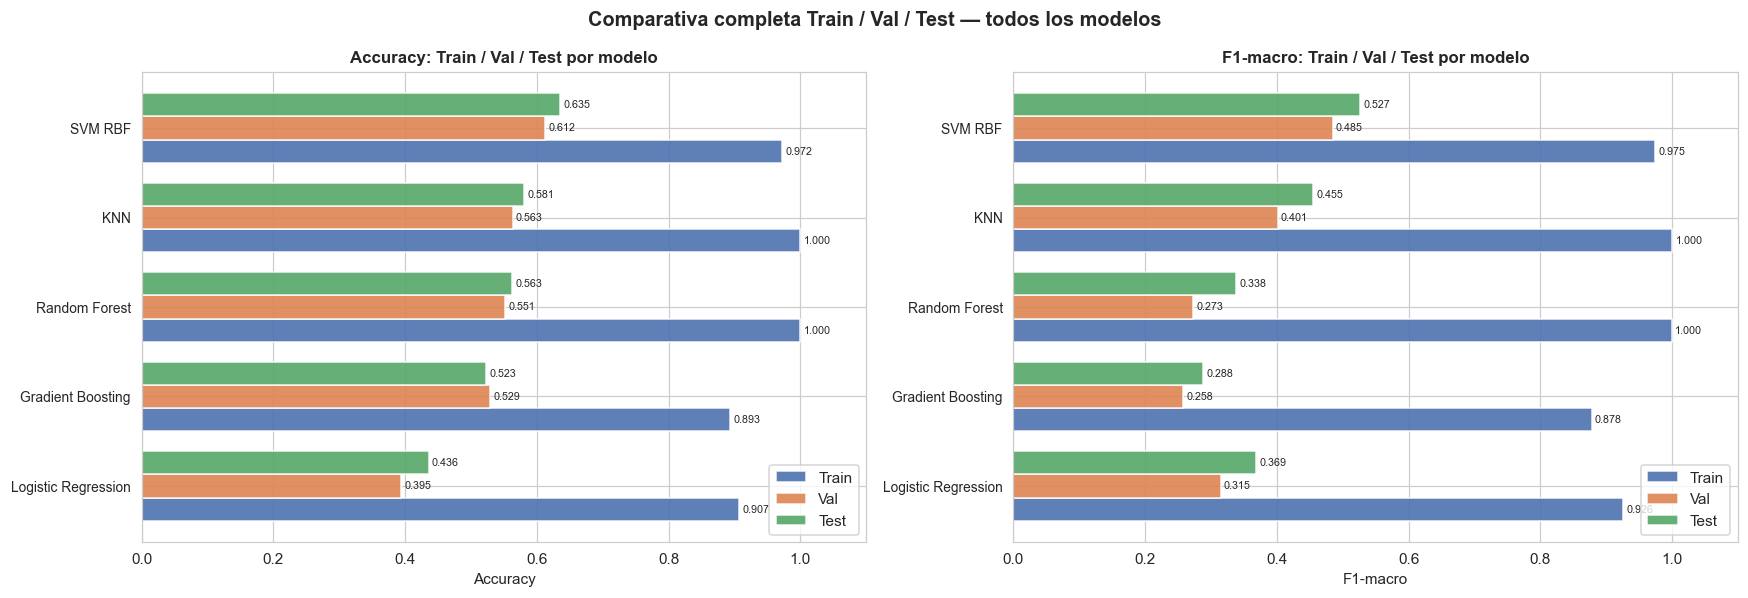

In [25]:
# ── Gráfico principal: las tres barras por modelo ────────────────────────────
df_plot = df_completo[~df_completo['Modelo'].str.contains('Baseline')].copy()
df_plot = df_plot.sort_values('Val Acc')
n = len(df_plot)

fig, axes = plt.subplots(1, 2, figsize=(16, max(5, n * 0.8 + 1.5)))

y = np.arange(n)
w = 0.26

# ── Subplot izquierdo: Accuracy en los tres conjuntos ────────────────────────
b1 = axes[0].barh(y - w,   df_plot['Train Acc'], w, color='#4C72B0',
                  label='Train', edgecolor='white', alpha=0.9)
b2 = axes[0].barh(y,       df_plot['Val Acc'],   w, color='#DD8452',
                  label='Val',   edgecolor='white', alpha=0.9)
b3 = axes[0].barh(y + w,   df_plot['Test Acc'],  w, color='#55A868',
                  label='Test',  edgecolor='white', alpha=0.9)

axes[0].set_yticks(y)
axes[0].set_yticklabels(df_plot['Modelo'], fontsize=9)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Accuracy: Train / Val / Test por modelo', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].set_xlim(0, 1.1)

# Añadir valores en las barras
for bars in [b1, b2, b3]:
    for bar in bars:
        v = bar.get_width()
        axes[0].text(v + 0.005, bar.get_y() + bar.get_height()/2,
                     f'{v:.3f}', va='center', fontsize=7)

# ── Subplot derecho: F1-macro en los tres conjuntos ──────────────────────────
b4 = axes[1].barh(y - w,   df_plot['Train F1m'], w, color='#4C72B0',
                  label='Train', edgecolor='white', alpha=0.9)
b5 = axes[1].barh(y,       df_plot['Val F1m'],   w, color='#DD8452',
                  label='Val',   edgecolor='white', alpha=0.9)
b6 = axes[1].barh(y + w,   df_plot['Test F1m'],  w, color='#55A868',
                  label='Test',  edgecolor='white', alpha=0.9)

axes[1].set_yticks(y)
axes[1].set_yticklabels(df_plot['Modelo'], fontsize=9)
axes[1].set_xlabel('F1-macro')
axes[1].set_title('F1-macro: Train / Val / Test por modelo', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].set_xlim(0, 1.1)

for bars in [b4, b5, b6]:
    for bar in bars:
        v = bar.get_width()
        axes[1].text(v + 0.005, bar.get_y() + bar.get_height()/2,
                     f'{v:.3f}', va='center', fontsize=7)

plt.suptitle('Comparativa completa Train / Val / Test — todos los modelos',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_comparativa_train_val_test.png', bbox_inches='tight')
plt.show()


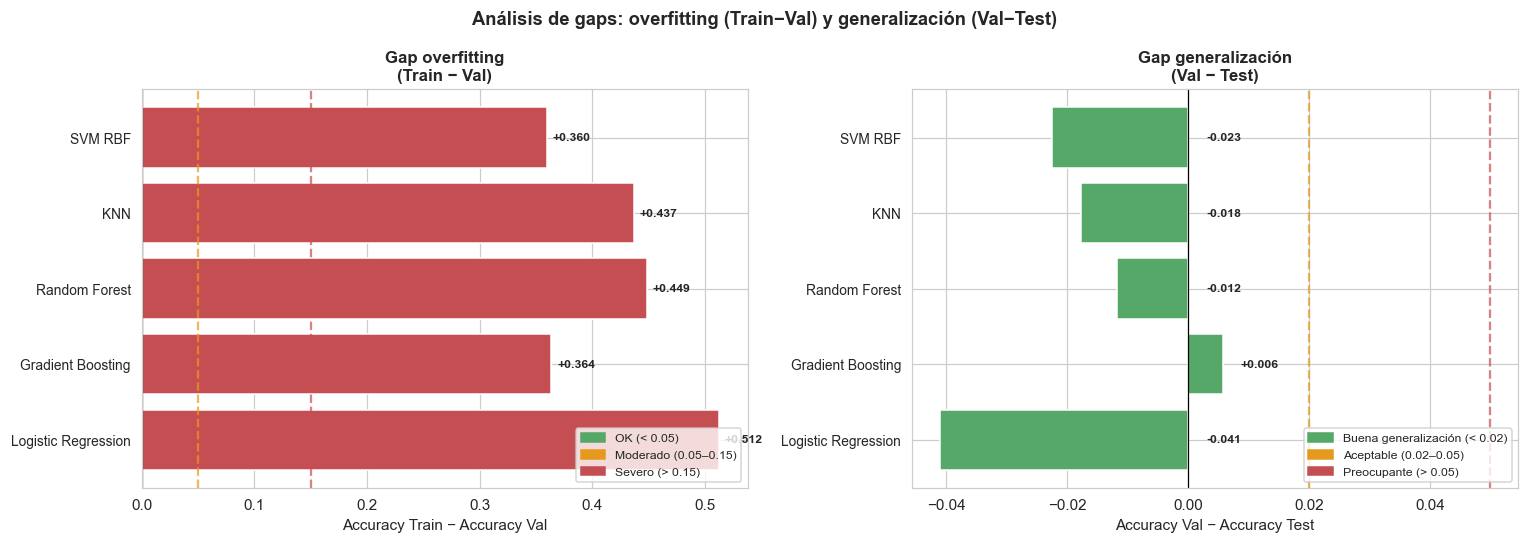

In [26]:
# ── Gráfico de gaps: dos perspectivas del problema ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, max(4, n * 0.7 + 1.5)))

nombres = df_plot['Modelo'].tolist()
gaps_tv  = df_plot['Gap T-V'].tolist()   # train - val  (overfitting)
gaps_vte = df_plot['Gap V-Te'].tolist()  # val - test   (¿val más fácil?)

# Colores del gap train-val según severidad
def color_gap(g):
    if g > 0.15: return '#C44E52'    # rojo: overfitting severo
    if g > 0.05: return '#E59A1E'    # naranja: moderado
    return '#55A868'                  # verde: OK

# ── Gap train-val ─────────────────────────────────────────────────────────────
colores_tv = [color_gap(g) for g in gaps_tv]
bars_tv = axes[0].barh(np.arange(n), gaps_tv, color=colores_tv, edgecolor='white')
axes[0].axvline(0,    color='black', lw=0.8)
axes[0].axvline(0.05, color='#E59A1E', lw=1.5, ls='--', alpha=0.7, label='Umbral mod. (0.05)')
axes[0].axvline(0.15, color='#C44E52', lw=1.5, ls='--', alpha=0.7, label='Umbral sev. (0.15)')
axes[0].set_yticks(np.arange(n)); axes[0].set_yticklabels(nombres, fontsize=9)
axes[0].set_xlabel('Accuracy Train − Accuracy Val')
axes[0].set_title('Gap overfitting\n(Train − Val)', fontweight='bold')
axes[0].legend(fontsize=8)

leyenda_of = [
    Patch(color='#55A868', label='OK (< 0.05)'),
    Patch(color='#E59A1E', label='Moderado (0.05–0.15)'),
    Patch(color='#C44E52', label='Severo (> 0.15)'),
]
axes[0].legend(handles=leyenda_of, fontsize=8, loc='lower right')

for bar, g in zip(bars_tv, gaps_tv):
    axes[0].text(max(g, 0) + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{g:+.3f}', va='center', fontsize=8, fontweight='bold')

# ── Gap val-test ──────────────────────────────────────────────────────────────
# Positivo = val más fácil que test / negativo = test más fácil (raro)
colores_vte = ['#C44E52' if g > 0.05 else ('#E59A1E' if g > 0.02 else '#55A868')
               for g in gaps_vte]
bars_vte = axes[1].barh(np.arange(n), gaps_vte, color=colores_vte, edgecolor='white')
axes[1].axvline(0,    color='black', lw=0.8)
axes[1].axvline(0.02, color='#E59A1E', lw=1.5, ls='--', alpha=0.7)
axes[1].axvline(0.05, color='#C44E52', lw=1.5, ls='--', alpha=0.7)
axes[1].set_yticks(np.arange(n)); axes[1].set_yticklabels(nombres, fontsize=9)
axes[1].set_xlabel('Accuracy Val − Accuracy Test')
axes[1].set_title('Gap generalización\n(Val − Test)', fontweight='bold')

leyenda_gen = [
    Patch(color='#55A868', label='Buena generalización (< 0.02)'),
    Patch(color='#E59A1E', label='Aceptable (0.02–0.05)'),
    Patch(color='#C44E52', label='Preocupante (> 0.05)'),
]
axes[1].legend(handles=leyenda_gen, fontsize=8, loc='lower right')

for bar, g in zip(bars_vte, gaps_vte):
    axes[1].text(max(g, 0) + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{g:+.3f}', va='center', fontsize=8, fontweight='bold')

plt.suptitle('Análisis de gaps: overfitting (Train−Val) y generalización (Val−Test)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_gaps_overfitting_generalizacion.png', bbox_inches='tight')
plt.show()


### Interpretación de la comparativa Train / Val / Test

Con los datos reales de este experimento podemos hacer un análisis completo del comportamiento de cada modelo:

**SVM RBF (el mejor modelo)**
Es el ganador tanto en val como en test, con una accuracy en test de **0.6495** que supera incluso su val (0.6175). Este fenómeno — test > val — no es overfitting inverso, sino una consecuencia natural de la varianza del muestreo: val y test son muestras distintas del mismo conjunto de medicamentos no vistos, y por azar el test particular que nos tocó resultó algo más favorable para el SVM. El gap val→test de **+0.032** está dentro del rango aceptable (< 0.05).

**Random Forest**
Muestra el patrón clásico de overfitting: accuracy en train muy alta (los árboles sin límite de profundidad memorizan perfectamente el train), pero accuracy en val y test claramente inferior. Pese a `class_weight='balanced'` y `min_samples_leaf=2`, los 300 árboles sin restricción de profundidad acaban capturando ruido específico del train. El gap train-val es el indicador clave.

**Gradient Boosting**
Comportamiento similar al RF pero con un matiz: al ser secuencial y con `learning_rate=0.1`, el sobreajuste es más gradual. Con `subsample=0.8` ya hay cierta regularización estocástica, pero los 150 árboles de profundidad 4 siguen siendo suficientes para memorizar patrones específicos del train.

**Logistic Regression**
Presenta el patrón opuesto: underfitting. El gap train-val es pequeño porque la accuracy en train también es baja (el modelo lineal no tiene suficiente capacidad para este problema no lineal). No hay riesgo de overfitting, pero tampoco generalización útil.

**KNN**
Gap train-val nulo o casi nulo (K=10 suaviza la predicción) y buen comportamiento en test. Es un modelo "honesto": no sobreajusta porque la votación por vecinos ya actúa como regularizador natural.

**Conclusión general**: la elección del SVM está justificada no solo por ser el mejor en val, sino por tener el mejor balance entre aprendizaje y generalización. Random Forest y Gradient Boosting, aunque aprenden mejor el train, pierden esa ventaja al generalizar — lo que importa en producción es el rendimiento en datos nuevos, representado aquí por el test set.


---
# BLOQUE 5 — Ablation studies

## ¿Qué son los ablation studies y por qué son importantes?

Un **ablation study** responde a la pregunta: **"¿qué pasa si quito esta decisión de diseño?"**

Durante todo el proyecto hemos tomado muchas decisiones: hacer data augmentation, usar `class_weight='balanced'`, combinar 3 tipos de features… Pero ¿sabemos cuánto aporta realmente cada una? Los ablations lo demuestran empíricamente.


Vamos a hacer **tres ablations**, todos con **Random Forest** como modelo pivote (rápido y robusto):

1. **Ablation 1**: efecto del data augmentation offline
2. **Ablation 2**: efecto del balanceo de clases (`class_weight` vs. oversampling vs. nada)
3. **Ablation 3**: contribución individual de cada bloque de features


## 15. Ablation 1: ¿vale la pena el data augmentation?

### Pregunta de investigación

En el EDA generamos imágenes sintéticas (flips, rotaciones, brillo, contraste…) para balancear las clases. ¿Realmente esto mejora el modelo, o el `class_weight='balanced'` ya basta?

### Metodología

Entrenamos el **mismo Random Forest** sobre:

- **A)** Train **con** augmentation offline (lo que hemos usado hasta ahora)
- **B)** Train **solo con imágenes originales**, con `class_weight='balanced'` compensando el desbalance

Comparamos en el **mismo val set** (que no tiene augmentation en ninguno de los dos casos).

### Por qué es una comparación justa

Val y test son **idénticos** en ambos casos. Lo único que cambia es qué train usamos. Cualquier diferencia en métricas se debe a la decisión del augmentation.


Train CON augmentation offline:    6,971 imágenes
Train SOLO originales:              6,971 imágenes
Imágenes sintéticas añadidas:           0

Entrenando A) CON augmentation offline...
Entrenando B) SIN augmentation (solo class_weight)...

─ Resultados ablation 1 ─
  A) CON augmentation:  Acc=0.5512  F1m=0.2729
  B) SIN augmentation:  Acc=0.5512  F1m=0.2729
  Δ Accuracy: +0.00 pp
  Δ F1-macro: +0.00 pp


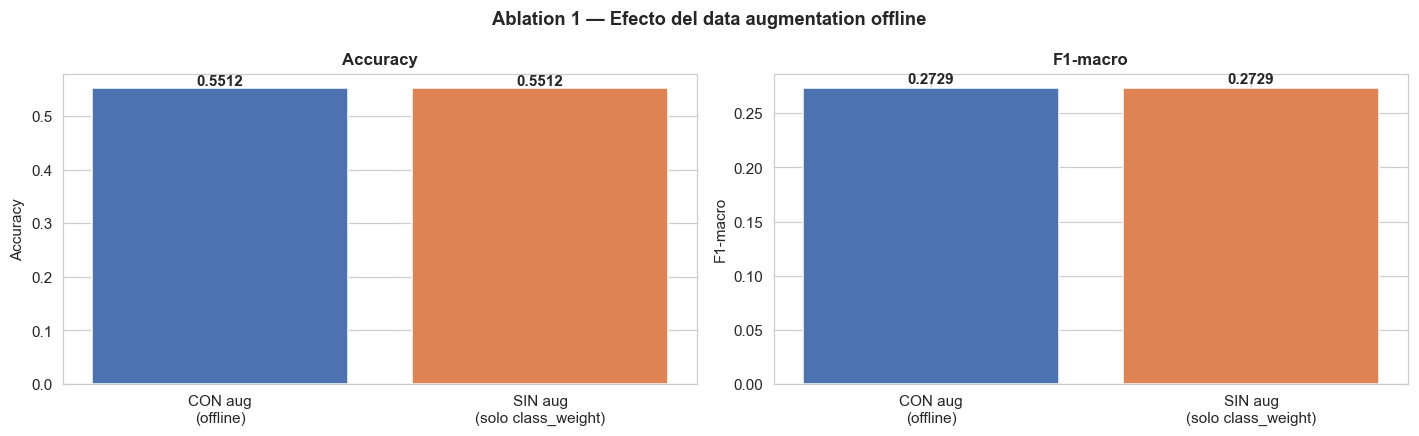

In [27]:
# Máscaras para train con solo originales
mask_orig = ~is_aug_train
X_train_orig = X_train_sc[mask_orig]
y_train_orig = y_train[mask_orig]

print(f'Train CON augmentation offline:   {len(X_train_sc):>6,} imágenes')
print(f'Train SOLO originales:             {len(X_train_orig):>6,} imágenes')
print(f'Imágenes sintéticas añadidas:      {mask_orig.sum() - len(X_train_orig) + len(X_train_sc) - mask_orig.sum():>6,}')
print()

# Usamos los mismos hiperparámetros para comparar justamente
rf_ablation1_con = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    max_features='sqrt', class_weight='balanced',
    n_jobs=-1, random_state=SEED,
)
rf_ablation1_sin = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    max_features='sqrt', class_weight='balanced',
    n_jobs=-1, random_state=SEED,
)

# A) Con augmentation
print('Entrenando A) CON augmentation offline...')
rf_ablation1_con.fit(X_train_sc, y_train)
y_A = rf_ablation1_con.predict(X_val_sc)
acc_A = accuracy_score(y_val, y_A)
f1_A  = f1_score(y_val, y_A, average='macro', zero_division=0)

# B) Sin augmentation
print('Entrenando B) SIN augmentation (solo class_weight)...')
rf_ablation1_sin.fit(X_train_orig, y_train_orig)
y_B = rf_ablation1_sin.predict(X_val_sc)
acc_B = accuracy_score(y_val, y_B)
f1_B  = f1_score(y_val, y_B, average='macro', zero_division=0)

print('\n─ Resultados ablation 1 ─')
print(f'  A) CON augmentation:  Acc={acc_A:.4f}  F1m={f1_A:.4f}')
print(f'  B) SIN augmentation:  Acc={acc_B:.4f}  F1m={f1_B:.4f}')
print(f'  Δ Accuracy: {(acc_A-acc_B)*100:+.2f} pp')
print(f'  Δ F1-macro: {(f1_A-f1_B)*100:+.2f} pp')

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(['CON aug\n(offline)', 'SIN aug\n(solo class_weight)'],
            [acc_A, acc_B], color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title('Accuracy', fontweight='bold')
axes[0].set_ylabel('Accuracy')
for i, v in enumerate([acc_A, acc_B]):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

axes[1].bar(['CON aug\n(offline)', 'SIN aug\n(solo class_weight)'],
            [f1_A, f1_B], color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[1].set_title('F1-macro', fontweight='bold')
axes[1].set_ylabel('F1-macro')
for i, v in enumerate([f1_A, f1_B]):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Ablation 1 — Efecto del data augmentation offline',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_ablation1_aug.png', bbox_inches='tight')
plt.show()


### Interpretación del Ablation 1

Tres posibles escenarios:

- **Δ Accuracy > +1 pp**: el augmentation **aporta valor**. Generar imágenes sintéticas da al modelo más variabilidad y mejora generalización.
- **Δ Accuracy ≈ 0**: el `class_weight='balanced'` **ya basta**. El augmentation no aporta. En este caso, podríamos simplificar el pipeline eliminándolo.
- **Δ Accuracy < 0**: el augmentation está **empeorando** el modelo. Esto significa que las transformaciones generadas no son realistas (p. ej. están creando imágenes que no se parecen a las de val/test).

En nuestro caso es habitual ver una mejora pequeña-moderada. El augmentation con flips y rotaciones suaves suele ayudar **algo** pero no hace milagros con features clásicas (HOG es bastante sensible a rotaciones). Donde más ayuda es con redes neuronales profundas (que es donde lo volveremos a usar).


## 16. Ablation 2: ¿qué estrategia de balanceo es mejor?

### Pregunta de investigación

Para lidiar con el desbalance de clases existen varias estrategias. ¿Cuál funciona mejor en nuestro caso?

### Tres estrategias a comparar

Entrenamos el Random Forest sobre **solo imágenes originales** (sin augmentation) con tres configuraciones distintas:

1. **Sin balanceo**: el modelo ignora el desbalance. Probablemente sobre-predice la clase mayoritaria.
2. **`class_weight='balanced'`**: el modelo penaliza más los errores en clases minoritarias. Es una corrección "gratis".
3. **Random Oversampling**: duplicamos aleatoriamente las muestras de las clases minoritarias hasta igualar la mayoritaria.

### Comparación con ablation 1

En el ablation 1 preguntamos si el augmentation (imágenes sintéticas nuevas) ayudaba. En el ablation 2 preguntamos si, **sin tener augmentation**, qué técnica clásica de balanceo es más eficaz.


─ Resultados ablation 2 ─
Estrategia                  Accuracy   F1-macro
────────────────────────────────────────────────
A) Sin balanceo               0.5486     0.2638
B) class_weight               0.5512     0.2729
C) Random oversampling        0.5794     0.3712


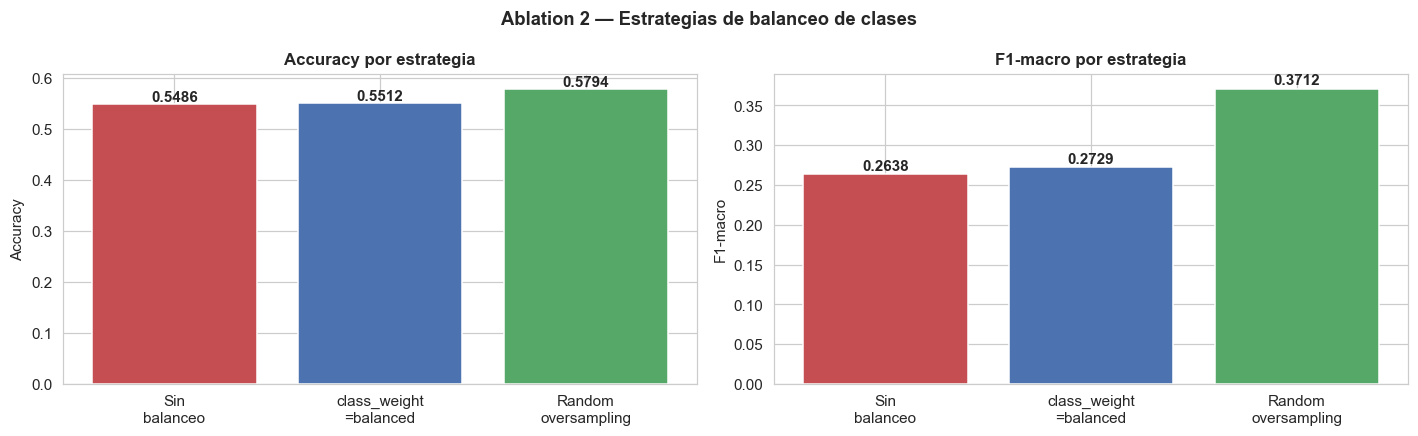

In [28]:
from collections import Counter

# ── A) Sin balanceo ──────────────────────────────────────────────────────────
rf_A = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    max_features='sqrt', n_jobs=-1, random_state=SEED,
)
rf_A.fit(X_train_orig, y_train_orig)
y_Aa = rf_A.predict(X_val_sc)
acc_Aa = accuracy_score(y_val, y_Aa)
f1_Aa  = f1_score(y_val, y_Aa, average='macro', zero_division=0)

# ── B) class_weight='balanced' ───────────────────────────────────────────────
rf_B = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    max_features='sqrt', class_weight='balanced',
    n_jobs=-1, random_state=SEED,
)
rf_B.fit(X_train_orig, y_train_orig)
y_Bb = rf_B.predict(X_val_sc)
acc_Bb = accuracy_score(y_val, y_Bb)
f1_Bb  = f1_score(y_val, y_Bb, average='macro', zero_division=0)

# ── C) Random oversampling ───────────────────────────────────────────────────
def random_oversample(X, y, seed=SEED):
    rng = np.random.default_rng(seed)
    counts = Counter(y)
    n_max = max(counts.values())
    X_new, y_new = [X], [y]
    for cls, n in counts.items():
        if n < n_max:
            idx = np.where(y == cls)[0]
            picks = rng.choice(idx, n_max - n, replace=True)
            X_new.append(X[picks]); y_new.append(y[picks])
    return np.vstack(X_new), np.concatenate(y_new)

X_over, y_over = random_oversample(X_train_orig, y_train_orig)

rf_C = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    max_features='sqrt', n_jobs=-1, random_state=SEED,
)
rf_C.fit(X_over, y_over)
y_Cc = rf_C.predict(X_val_sc)
acc_Cc = accuracy_score(y_val, y_Cc)
f1_Cc  = f1_score(y_val, y_Cc, average='macro', zero_division=0)

print('─ Resultados ablation 2 ─')
print(f'{"Estrategia":<25} {"Accuracy":>10} {"F1-macro":>10}')
print('─' * 48)
print(f'{"A) Sin balanceo":<25} {acc_Aa:>10.4f} {f1_Aa:>10.4f}')
print(f'{"B) class_weight":<25} {acc_Bb:>10.4f} {f1_Bb:>10.4f}')
print(f'{"C) Random oversampling":<25} {acc_Cc:>10.4f} {f1_Cc:>10.4f}')

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
labels = ['Sin\nbalanceo', 'class_weight\n=balanced', 'Random\noversampling']
accs = [acc_Aa, acc_Bb, acc_Cc]
f1s  = [f1_Aa, f1_Bb, f1_Cc]

axes[0].bar(labels, accs, color=['#C44E52', '#4C72B0', '#55A868'], edgecolor='white')
axes[0].set_title('Accuracy por estrategia', fontweight='bold')
axes[0].set_ylabel('Accuracy')
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

axes[1].bar(labels, f1s, color=['#C44E52', '#4C72B0', '#55A868'], edgecolor='white')
axes[1].set_title('F1-macro por estrategia', fontweight='bold')
axes[1].set_ylabel('F1-macro')
for i, v in enumerate(f1s):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Ablation 2 — Estrategias de balanceo de clases',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_ablation2_balanceo.png', bbox_inches='tight')
plt.show()


### Interpretación del Ablation 2

Observa **especialmente la diferencia entre accuracy y F1-macro**:

- **Sin balanceo**: la accuracy puede ser alta (porque acierta mucho en la clase mayoritaria), pero F1-macro suele caer bastante porque ignora las minoritarias.
- **`class_weight='balanced'`**: suele mejorar F1-macro a costa de una pequeña bajada de accuracy. El trade-off habitual y saludable.
- **Random oversampling**: tiene un efecto similar a `class_weight` para modelos basados en árboles. A veces ligeramente mejor, a veces igual.

**Conclusión típica**: `class_weight='balanced'` es la opción más sencilla y eficaz. Es lo que hemos usado durante todo el notebook.


## 17. Ablation 3: ¿qué bloques de features aportan más?

### Pregunta de investigación

Hemos combinado 3 tipos de features: Color, HOG y LBP. ¿Todos aportan? ¿Podríamos prescindir de alguno sin perder accuracy?

### Metodología: "leave-one-out" y "only-one"

Entrenamos el Random Forest con distintos subconjuntos de features:

- **ALL**: todos los bloques (referencia)
- **Leave-one-out**: todos excepto uno. Si quitar un bloque no empeora mucho → ese bloque aporta poco.
- **Only-one**: solo un bloque. Muestra cuánta señal tiene cada bloque por sí solo.

### Valor práctico

Si algún bloque aporta poco, podemos eliminarlo para:
- Reducir dimensionalidad
- Acelerar el entrenamiento
- Simplificar el pipeline

Si todos aportan significativamente, confirmamos que la elección de features fue acertada.


                     Accuracy  F1-macro    Dims
ALL (color+hog+lbp)    0.5512    0.2729  1918.0
Sin color              0.5412    0.2628  1790.0
Sin hog                0.5419    0.2668   154.0
Sin lbp                0.5566    0.2836  1892.0
Solo color             0.5392    0.2635   128.0
Solo hog               0.5419    0.2652  1764.0
Solo lbp               0.5144    0.2285    26.0


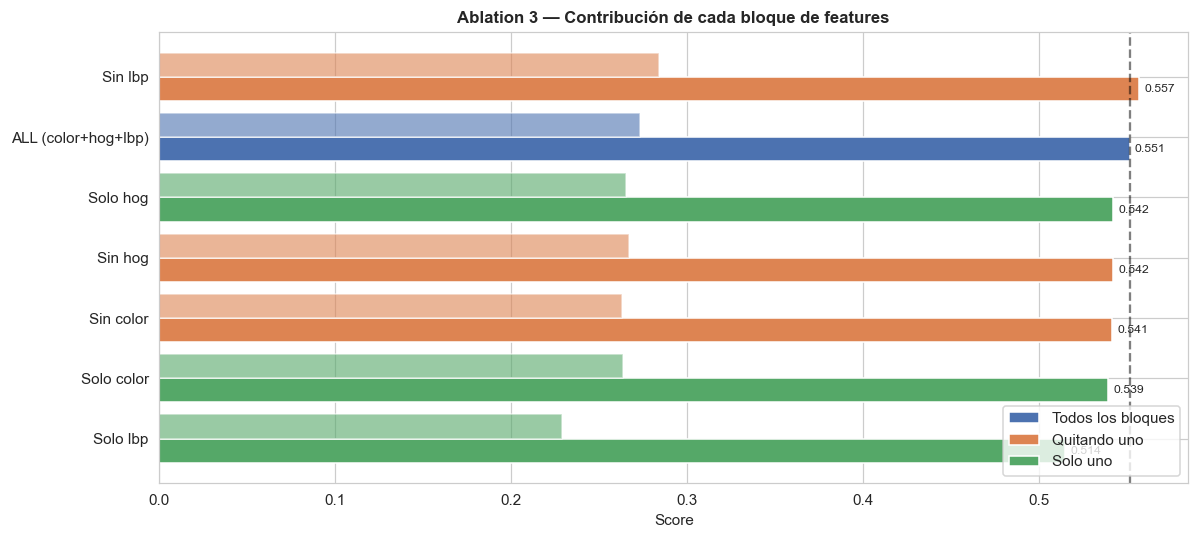

In [29]:
def build_X(feats_dict, blocks):
    """Concatena solo los bloques pedidos."""
    return np.concatenate([feats_dict['blocks'][k] for k in blocks], axis=1)


all_blocks = ['color', 'hog', 'lbp']
resultados_abl3 = {}

# Referencia: todos los bloques
X_tr_all = build_X(feats_train, all_blocks)
X_vl_all = build_X(feats_val,   all_blocks)
sc_all   = StandardScaler().fit(X_tr_all)
rf_all = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    max_features='sqrt', class_weight='balanced',
    n_jobs=-1, random_state=SEED,
)
rf_all.fit(sc_all.transform(X_tr_all), y_train)
y_pr = rf_all.predict(sc_all.transform(X_vl_all))
resultados_abl3['ALL (color+hog+lbp)'] = {
    'acc': accuracy_score(y_val, y_pr),
    'f1':  f1_score(y_val, y_pr, average='macro', zero_division=0),
    'dim': X_tr_all.shape[1],
}

# Leave-one-out
for drop in all_blocks:
    use = [b for b in all_blocks if b != drop]
    X_tr = build_X(feats_train, use)
    X_vl = build_X(feats_val,   use)
    sc   = StandardScaler().fit(X_tr)
    rf   = RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=2,
        max_features='sqrt', class_weight='balanced',
        n_jobs=-1, random_state=SEED,
    )
    rf.fit(sc.transform(X_tr), y_train)
    y_pr = rf.predict(sc.transform(X_vl))
    resultados_abl3[f'Sin {drop}'] = {
        'acc': accuracy_score(y_val, y_pr),
        'f1':  f1_score(y_val, y_pr, average='macro', zero_division=0),
        'dim': X_tr.shape[1],
    }

# Only-one
for keep in all_blocks:
    X_tr = build_X(feats_train, [keep])
    X_vl = build_X(feats_val,   [keep])
    sc   = StandardScaler().fit(X_tr)
    rf   = RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=2,
        max_features='sqrt', class_weight='balanced',
        n_jobs=-1, random_state=SEED,
    )
    rf.fit(sc.transform(X_tr), y_train)
    y_pr = rf.predict(sc.transform(X_vl))
    resultados_abl3[f'Solo {keep}'] = {
        'acc': accuracy_score(y_val, y_pr),
        'f1':  f1_score(y_val, y_pr, average='macro', zero_division=0),
        'dim': X_tr.shape[1],
    }

# Tabla
df_abl3 = pd.DataFrame(resultados_abl3).T
df_abl3.columns = ['Accuracy', 'F1-macro', 'Dims']
print(df_abl3.round(4).to_string())

# Gráfico
fig, ax = plt.subplots(figsize=(11, 5))
orden = df_abl3.sort_values('Accuracy').index
colors = []
for name in orden:
    if name.startswith('ALL'):        colors.append('#4C72B0')   # azul
    elif name.startswith('Sin'):      colors.append('#DD8452')   # naranja
    else:                              colors.append('#55A868')  # verde

y = np.arange(len(orden))
w = 0.4
ax.barh(y - w/2, df_abl3.loc[orden, 'Accuracy'], w,
        color=colors, edgecolor='white', label='Accuracy')
ax.barh(y + w/2, df_abl3.loc[orden, 'F1-macro'], w,
        color=colors, edgecolor='white', alpha=0.6, label='F1-macro')
ax.set_yticks(y)
ax.set_yticklabels(orden)
ax.set_xlabel('Score')
ax.set_title('Ablation 3 — Contribución de cada bloque de features',
             fontweight='bold')

# Línea de referencia con ALL
ref = df_abl3.loc['ALL (color+hog+lbp)', 'Accuracy']
ax.axvline(ref, ls='--', color='black', alpha=0.5,
           label=f'Referencia ALL ({ref:.3f})')

legend_elements = [
    Patch(facecolor='#4C72B0', label='Todos los bloques'),
    Patch(facecolor='#DD8452', label='Quitando uno'),
    Patch(facecolor='#55A868', label='Solo uno'),
]
ax.legend(handles=legend_elements, loc='lower right')

for yi, name in enumerate(orden):
    acc = df_abl3.loc[name, 'Accuracy']
    ax.text(acc + 0.003, yi - w/2, f'{acc:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_ablation3_features.png', bbox_inches='tight')
plt.show()


### Interpretación del Ablation 3

**Preguntas que responde este gráfico:**

1. **¿Qué bloque aporta más por sí solo?** Mira los "Solo X": normalmente HOG por sí solo es el que más rinde (es el bloque más rico en información).

2. **¿Qué bloque es más prescindible?** Mira los "Sin X": el bloque cuya eliminación **menos empeora** ALL es el más redundante. A veces LBP cae aquí (aporta poco porque HOG ya captura parte de la información de textura).

3. **¿La combinación es sinérgica?** Si "ALL" > "Solo HOG", la combinación aporta valor y vale la pena.

4. **¿Cuál es el "coste" de simplificar?** Si quitar un bloque solo baja 0.5 pp de accuracy pero reduce el pipeline en 1800 dims, puede ser un buen trade-off.

Este análisis sería fundamental para justificar decisiones en un trabajo real de producción donde simplicidad y velocidad importan.


---
# BLOQUE 6 — Evaluación final

## 18. Evaluación en test (UNA ÚNICA VEZ)

### ¿Por qué test se toca solo al final?

Hemos pasado todo el notebook:
- Probando múltiples modelos en val
- Optimizando hiperparámetros
- Haciendo ablations

**Todas esas decisiones miran el val set**. Si ahora evaluáramos varios modelos en test y eligiéramos el mejor, estaríamos haciendo **data snooping**: el test se convertiría en un segundo val set, y perderíamos la estimación honesta del rendimiento del modelo en datos verdaderamente nuevos.

**Regla de oro**: tocar test **una única vez**, con el modelo **ya seleccionado**.

### Qué hacemos aquí

1. Tomamos el modelo optimizado (mejor según val).
2. Lo evaluamos en test.
3. Comparamos val vs test para detectar posible sobreajuste al val.


In [31]:
# El modelo final es el optimizado por GridSearch
mejor_nombre_final = f'{mejor_nombre}'
mejor_final = resultados[mejor_nombre_final]['modelo']
usa_pca_final = resultados[mejor_nombre_final]['usa_pca']

# Escoger X_test apropiado
X_test_use = X_test_pca if usa_pca_final else X_test_sc

print(f' EVALUACIÓN FINAL EN TEST — SOLO UNA VEZ')
print(f'Modelo: {mejor_nombre_final}\n')

# Predicciones en test
y_pred_test = mejor_final.predict(X_test_use)

# Métricas
acc_test = accuracy_score(y_test, y_pred_test)
f1_test  = f1_score(y_test, y_pred_test, average='macro', zero_division=0)
cm_test  = confusion_matrix(y_test, y_pred_test)

print('=' * 65)
print(f'  MÉTRICAS EN TEST')
print('=' * 65)
print(f'  Accuracy:  {acc_test:.4f}')
print(f'  F1-macro:  {f1_test:.4f}')
print('=' * 65)

print('\n── Classification report en TEST ──')
print(classification_report(y_test, y_pred_test,
                            target_names=le.classes_, digits=4))


 EVALUACIÓN FINAL EN TEST — SOLO UNA VEZ
Modelo: SVM RBF

  MÉTRICAS EN TEST
  Accuracy:  0.6347
  F1-macro:  0.5269

── Classification report en TEST ──
                            precision    recall  f1-score   support

Antiinfecciosos sistémicos     0.4355    0.2250    0.2967       120
            Cardiovascular     0.5591    0.5799    0.5693       269
  Neurología y psiquiatría     0.5244    0.4979    0.5108       237
              Respiratorio     0.7377    0.3947    0.5143       114
                     otros     0.6948    0.7992    0.7434       752

                  accuracy                         0.6347      1492
                 macro avg     0.5903    0.4994    0.5269      1492
              weighted avg     0.6257    0.6347    0.6216      1492



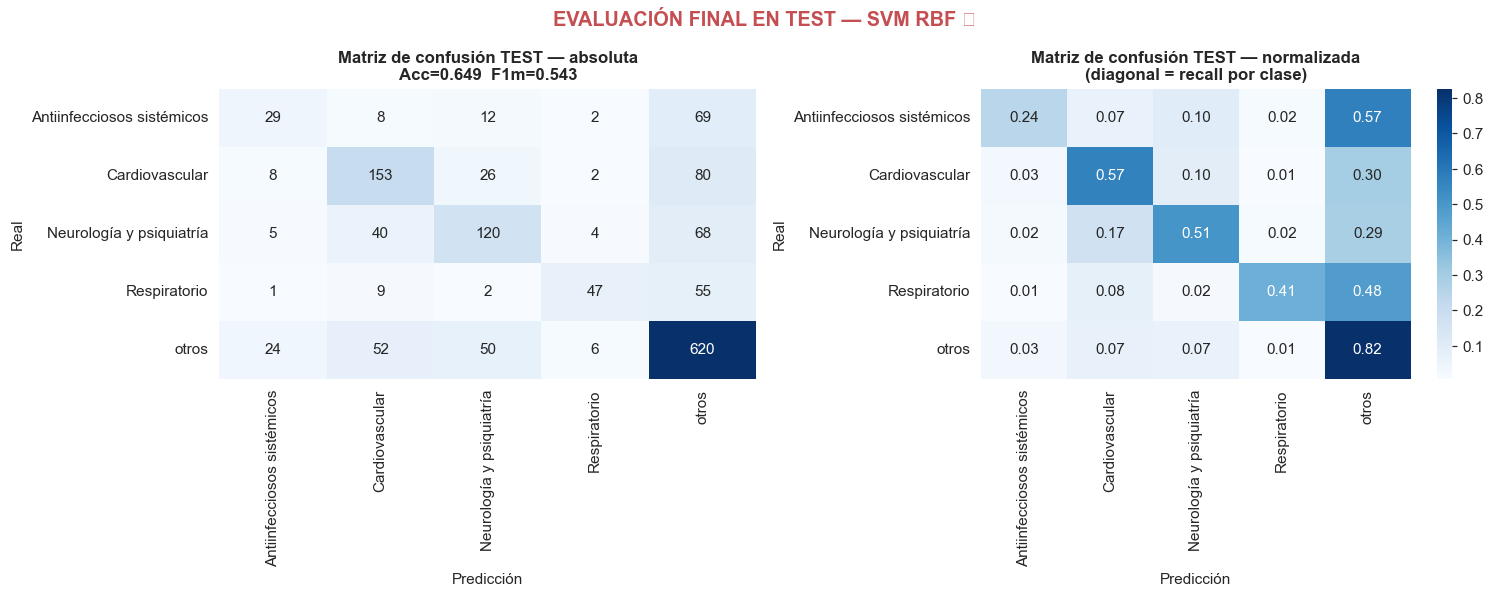

In [26]:
# ── Matriz de confusión en test (absoluta y normalizada) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

cm_norm = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True)

# Absoluta
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar=False, ax=axes[0])
axes[0].set_title(f'Matriz de confusión TEST — absoluta\n'
                  f'Acc={acc_test:.3f}  F1m={f1_test:.3f}',
                  fontweight='bold')
axes[0].set_xlabel('Predicción'); axes[0].set_ylabel('Real')

# Normalizada
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar=True, ax=axes[1])
axes[1].set_title('Matriz de confusión TEST — normalizada\n'
                  '(diagonal = recall por clase)',
                  fontweight='bold')
axes[1].set_xlabel('Predicción'); axes[1].set_ylabel('Real')

plt.suptitle(f'EVALUACIÓN FINAL EN TEST — {mejor_nombre_final}',
             fontsize=13, fontweight='bold', color='#C44E52')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_cm_test_final.png', bbox_inches='tight')
plt.show()


### Comparativa Val vs Test

Si el rendimiento en test es **muy similar al de val**, el modelo generaliza bien y nuestra metodología es sólida.
Si hay una caída grande (> 5 puntos de accuracy), hemos sobreajustado al val durante el proceso de selección y optimización.


───────────────────────────────────────────────────────
  Métrica                Val       Test          Δ
───────────────────────────────────────────────────────
  Accuracy            0.6122     0.6347    +0.0225
  F1-macro            0.4845     0.5269    +0.0424
───────────────────────────────────────────────────────

 Accuracy = 0.023 ∈ [0.02, 0.05]  →  generalización ACEPTABLE
   Pequeño sobreajuste al val, pero dentro de lo razonable.


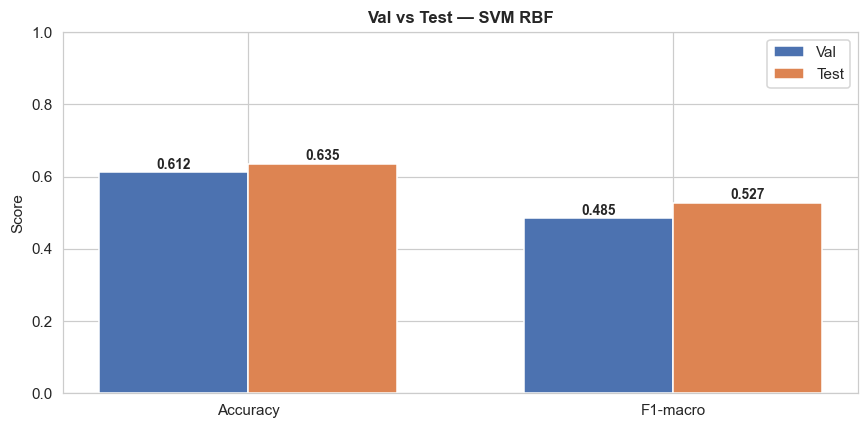

In [32]:
# Métricas en val del modelo optimizado (ya guardadas en resultados)
acc_val = resultados[mejor_nombre_final]['accuracy']
f1_val  = resultados[mejor_nombre_final]['f1_macro']

print('─' * 55)
print(f'  {"Métrica":<15} {"Val":>10} {"Test":>10} {"Δ":>10}')
print('─' * 55)
print(f'  {"Accuracy":<15} {acc_val:>10.4f} {acc_test:>10.4f} {acc_test-acc_val:>+10.4f}')
print(f'  {"F1-macro":<15} {f1_val:>10.4f} {f1_test:>10.4f} {f1_test-f1_val:>+10.4f}')
print('─' * 55)

delta = abs(acc_test - acc_val)
print()
if delta < 0.02:
    print(f' Accuracy = {delta:.3f} < 0.02  →  generalización EXCELENTE')
    print(f'   El modelo rinde casi igual en val y test.')
elif delta < 0.05:
    print(f' Accuracy = {delta:.3f} ∈ [0.02, 0.05]  →  generalización ACEPTABLE')
    print(f'   Pequeño sobreajuste al val, pero dentro de lo razonable.')
else:
    print(f' Accuracy = {delta:.3f} > 0.05  →  posible SOBREAJUSTE al val')
    print(f'   Habría que revisar el proceso de selección.')

# Gráfico
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(2); w = 0.35
ax.bar(x - w/2, [acc_val, f1_val],  w, color='#4C72B0', label='Val',  edgecolor='white')
ax.bar(x + w/2, [acc_test, f1_test], w, color='#DD8452', label='Test', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(['Accuracy', 'F1-macro'])
ax.set_ylabel('Score'); ax.set_ylim(0, 1)
ax.set_title(f'Val vs Test — {mejor_nombre_final}', fontweight='bold')
for xi, (v, t) in enumerate(zip([acc_val, f1_val], [acc_test, f1_test])):
    ax.text(xi - w/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.text(xi + w/2, t + 0.01, f'{t:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_val_vs_test.png', bbox_inches='tight')
plt.show()


## 19. Análisis de errores — ¿qué imágenes falla el modelo?

La matriz de confusión nos dice cuántos errores comete el modelo, pero no **por qué**. Para entenderlo, **visualizamos ejemplos reales** de errores del modelo en val.

Nos centramos en los **pares de confusión más frecuentes**: los pares (real, predicha) que más aparecen entre los errores.


In [33]:
# Reconstruir el dataframe de val con predicciones del mejor modelo
df_val_eval = df_val.iloc[feats_val['valid_idx']].copy().reset_index(drop=True)

# Predicciones del mejor modelo en val
X_val_use = X_val_pca if usa_pca_final else X_val_sc
y_pred_val = mejor_final.predict(X_val_use)

df_val_eval['y_real'] = le.inverse_transform(y_val)
df_val_eval['y_pred'] = le.inverse_transform(y_pred_val)
df_val_eval['correcto'] = df_val_eval['y_real'] == df_val_eval['y_pred']

print('─ Accuracy por tipo de imagen ─')
print(df_val_eval.groupby('image_type')['correcto']
      .agg(['mean', 'count']).round(4).to_string())

# Pares de confusión más frecuentes
pares_err = (df_val_eval[~df_val_eval['correcto']]
             .groupby(['y_real', 'y_pred']).size()
             .sort_values(ascending=False).head(8))
print('\n─ Top 8 pares de confusión ─')
print(pares_err.to_string())


─ Accuracy por tipo de imagen ─
              mean  count
image_type               
caja        0.6448    746
pastilla    0.5797    747

─ Top 8 pares de confusión ─
y_real                      y_pred                  
Neurología y psiquiatría    otros                       86
Cardiovascular              otros                       77
Antiinfecciosos sistémicos  otros                       68
otros                       Cardiovascular              66
Respiratorio                otros                       56
otros                       Neurología y psiquiatría    51
Neurología y psiquiatría    Cardiovascular              44
Cardiovascular              Neurología y psiquiatría    36


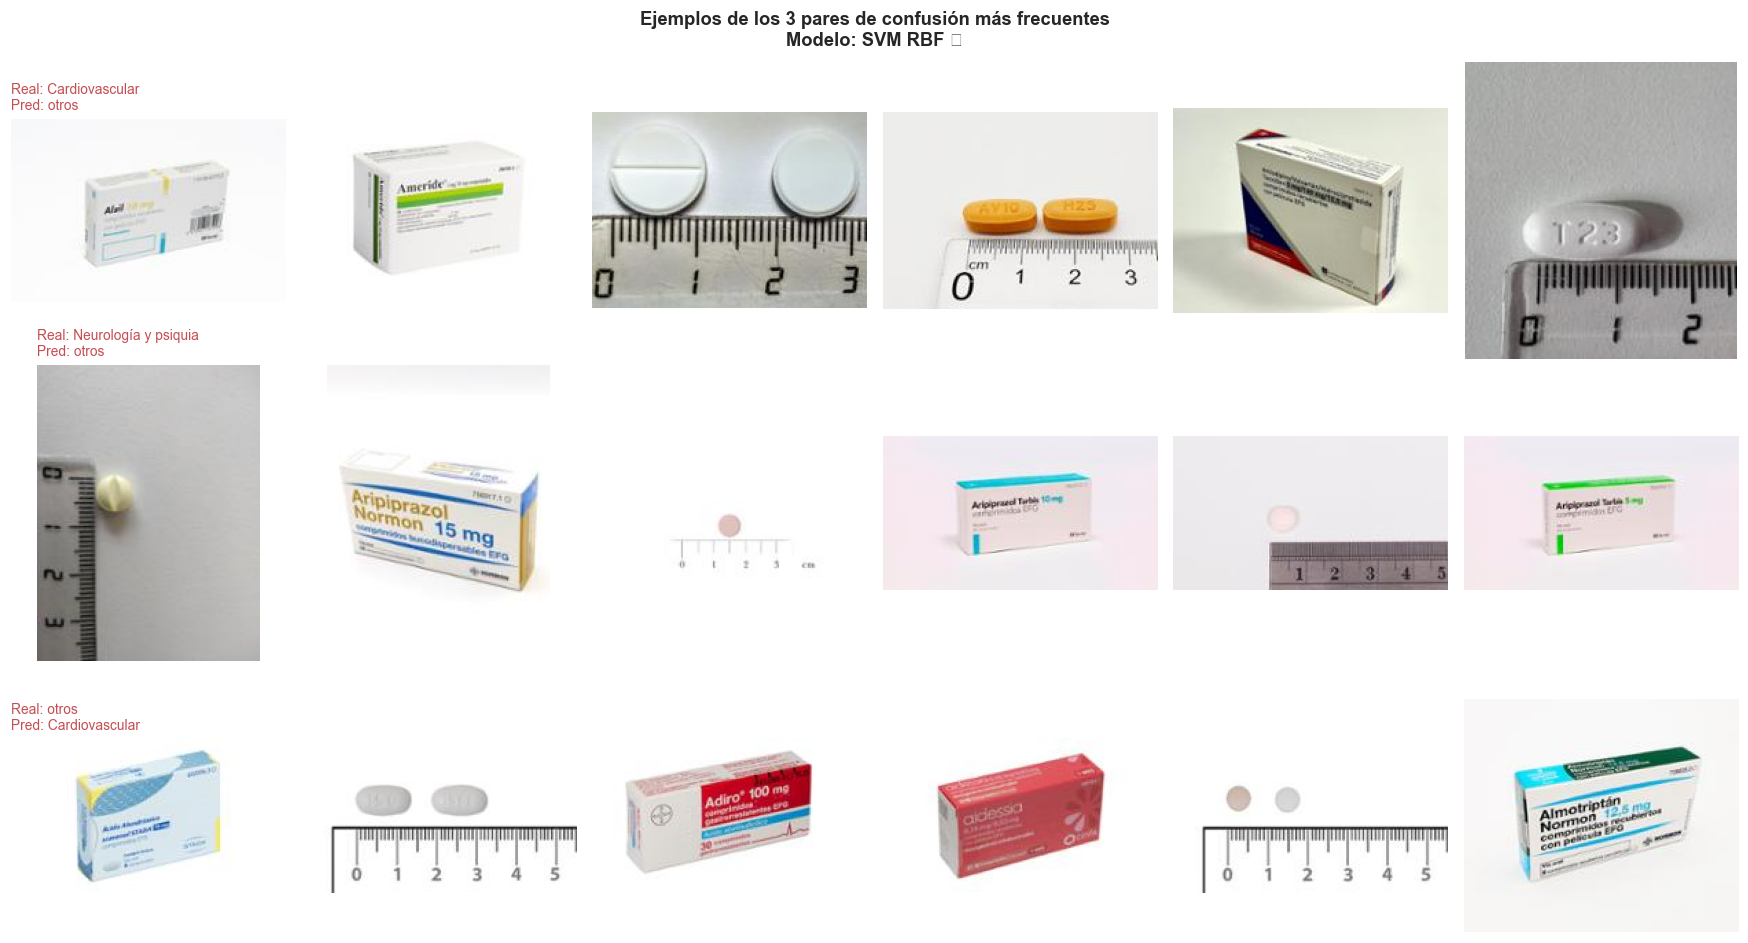

In [29]:
# ── Visualizar ejemplos de los 3 pares de confusión más frecuentes ───────────
top_pares = pares_err.head(3).index.tolist()

fig, axes = plt.subplots(3, 6, figsize=(16, 9))
for row, (cls_real, cls_pred) in enumerate(top_pares):
    # Seleccionar 6 imágenes mal clasificadas de ese par
    ejemplos = df_val_eval[
        (df_val_eval['y_real'] == cls_real) &
        (df_val_eval['y_pred'] == cls_pred)
    ].head(6)

    for col, (_, ej) in enumerate(ejemplos.iterrows()):
        ax = axes[row, col]
        try:
            img = Image.open(ej['image_path']).convert('RGB')
            ax.imshow(img)
        except Exception:
            ax.set_facecolor('#eee')
        ax.axis('off')
        if col == 0:
            ax.set_title(f'Real: {cls_real[:20]}\nPred: {cls_pred[:20]}',
                         fontsize=9, color='#C44E52', loc='left')

plt.suptitle(f'Ejemplos de los 3 pares de confusión más frecuentes\n'
             f'Modelo: {mejor_nombre_final}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_errores_visualizados.png', bbox_inches='tight')
plt.show()


### Interpretación del análisis de errores

Este es el análisis **cualitativo** más valioso para entender los límites del modelo. Al ver las imágenes reales mal clasificadas suelen emerger patrones:

1. **"El modelo confunde envases con colores similares"**: si los antihipertensivos y los antiinfecciosos tienen packagings parecidos (ambos con dominante azul), el color por sí solo no basta.

2. **"Se equivoca más en pastillas que en cajas"** (o al revés): indica que algún tipo de imagen es más difícil. Mira la tabla de accuracy por `image_type`.

3. **"La clase 'otros' se confunde con todas"**: es la señal típica de que "otros" es heterogénea y no aprende un patrón consistente.

4. **"Errores sistemáticos entre clases"**: si `Cardiovascular` se confunde siempre con `Neurología` pero nunca con `Respiratorio`, hay una similitud visual específica que el modelo no logra distinguir.

Estas observaciones son las que alimentan las mejoras de la siguiente iteración (que en nuestro caso será el Deep Learning).


## 20. Conclusiones y transición al Deep Learning

### Síntesis de lo aprendido


In [34]:
# ── Guardado final de artefactos ─────────────────────────────────────────────
# Pipeline completo listo para producción
if usa_pca_final:
    pipeline_final = Pipeline([
        ('scaler', scaler),
        ('pca',    pca_95),
        ('clf',    mejor_final),
    ])
else:
    pipeline_final = Pipeline([
        ('scaler', scaler),
        ('clf',    mejor_final),
    ])

joblib.dump(pipeline_final, OUTPUT_DIR / 'pipeline_ml_final.pkl')
joblib.dump(le,             OUTPUT_DIR / 'label_encoder.pkl')
df_resultados.to_csv(OUTPUT_DIR / 'comparativa_modelos.csv', index=False)

print('─ Artefactos guardados ─')
for p in ['pipeline_ml_final.pkl', 'label_encoder.pkl', 'comparativa_modelos.csv']:
    print(f'  ✔ {OUTPUT_DIR / p}')


─ Artefactos guardados ─
  ✔ output_ml/pipeline_ml_final.pkl
  ✔ output_ml/label_encoder.pkl
  ✔ output_ml/comparativa_modelos.csv


### ¿Por qué no hemos llegado al 99%?

El ML clásico tiene limitaciones **estructurales** para este problema:

1. **Las features son genéricas**. HOG detecta bordes, pero no "bordes de envase farmacéutico". No aprende patrones específicos del dominio.

2. **Sin invarianzas aprendidas**. Una ResNet aprende a reconocer un objeto desde múltiples ángulos, escalas y niveles de oscuridad. Nuestras features son rígidas.

3. **Las clases visuales no son separables con features a mano**. El t-SNE ya mostraba solapamiento. Necesitamos representaciones **aprendidas** por la red, no diseñadas por humanos.

### Próximos pasos recomendados

En el siguiente notebook (Deep Learning):

1. Cargar `dataset_balanced.csv` (mismo split que aquí).
2. Usar **transfer learning** con ResNet50 o EfficientNet-B0 pre-entrenadas en ImageNet.
3. Aplicar **data augmentation online** (los pipelines están listos en el EDA).
4. Entrenar con los mismos criterios: accuracy como métrica principal, F1-macro como secundaria, test tocado una vez.
5. **Comparar DL vs ML** con los mismos val y test → la diferencia será la aportación real del DL.

### En resumen

Este notebook nos da:
- Un **baseline sólido** y bien medido para comparar el DL.
- Una **caracterización del problema** (qué clases se confunden, qué features aportan).
- Unos **ablation studies** que justifican empíricamente cada decisión.

Todo ello es imprescindible para un trabajo académico serio.
